# 05_Main_Model - Multi-Representation Ensemble SER

Notebook này là bản 05 mới để test kiến trúc **Unified Feature Engineering -> Multi-Representation Ensemble**.

Khác với Tri-view gated fusion trước đó, bản này **không ép 3 nhánh feature trộn chung trong một model**. Thay vào đó:

1. Trích xuất feature từ cùng audio 16k bằng một pipeline thống nhất.
2. Tạo 3 biểu diễn khác nhau: temporal sequence, spectral image, statistical vector.
3. Train 3 model chuyên biệt.
4. Ensemble xác suất theo validation macro-F1.

Mục tiêu là tận dụng điểm mạnh của từng nhóm feature mà không để một nhánh yếu kéo hỏng toàn bộ embedding của model khác.


## Architecture

Notebook này dùng cách trình bày **3 nhánh** để dễ báo cáo và dễ ablation:

```text
Audio 16 kHz
   |
   v
Unified Feature Engineering
   |
   |-- Branch 1: Temporal acoustic branch
   |     MFCC + delta + delta-delta + RMS + ZCR + spectral features
   |     -> 1D-CNN + BiGRU + temporal attention
   |
   |-- Branch 2: Pretrained spectrogram branch
   |     log-Mel spectrogram representation
   |     -> audio-pretrained spectrogram encoder + small classifier head
   |
   |-- Branch 3: Statistical acoustic branch
         MFCC/chroma/spectral/RMS/ZCR/energy statistics
         -> RBF-SVM

Final prediction:
validation-weighted average of the three branch probabilities.
```

Trong bản mặc định, nhánh 2 dùng checkpoint audio-pretrained cho spectrogram. Nếu môi trường Kaggle không tải được `transformers`/checkpoint, notebook tự fallback về 2D-CNN + SE attention để không bị gãy pipeline.

Notebook vẫn đánh giá theo 3 nhóm protocol:

- `combined_random`: gộp các dataset rồi chia ngẫu nhiên train/validation/test. Protocol này gần với nhiều paper báo điểm cao, nhưng cần ghi rõ rủi ro model học pattern riêng của speaker/corpus.
- `combined_strict_no_tess`: chia theo speaker/corpus-aware nghiêm hơn và loại TESS khỏi strict vì TESS có rất ít speaker. Protocol này dùng để kiểm tra generalization tốt hơn.
- `single-dataset experiments`: train và test riêng trên từng dataset để so sánh với các paper thường báo kết quả theo từng corpus.


In [1]:
# ============================================================
# 1. Imports
# ============================================================
import os
import json
import time
import random
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import librosa
import soundfile as sf

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

SEED = int(os.getenv("SEED", "42"))
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DISABLE_CUDNN_RNN = os.getenv("DISABLE_CUDNN_RNN", "1") == "1"
if DISABLE_CUDNN_RNN:
    torch.backends.cudnn.enabled = False

print("Device:", DEVICE)
print("cuDNN enabled:", torch.backends.cudnn.enabled)


Device: cuda
cuDNN enabled: False


In [2]:
# ============================================================
# 2. Configuration
# ============================================================
QUICK_RUN = os.getenv("QUICK_RUN", "0") == "1"
QUICK_RUN_PER_GROUP = int(os.getenv("QUICK_RUN_PER_GROUP", "24"))

TARGET_SR = 16_000
TARGET_DURATION = float(os.getenv("TARGET_DURATION", "3.0"))
TARGET_LENGTH = int(TARGET_SR * TARGET_DURATION)
N_FFT = int(os.getenv("N_FFT", "400"))
WIN_LENGTH = int(os.getenv("WIN_LENGTH", "400"))
HOP_LENGTH = int(os.getenv("HOP_LENGTH", "160"))
N_MFCC = int(os.getenv("N_MFCC", "40"))
N_MELS = int(os.getenv("N_MELS", "96"))
MAX_FRAMES = int(1 + TARGET_LENGTH // HOP_LENGTH)

COMMON_EMOTIONS = ["neutral", "happy", "sad", "angry", "fear", "disgust"]
LABEL_TO_ID = {label: i for i, label in enumerate(COMMON_EMOTIONS)}
ID_TO_LABEL = {i: label for label, i in LABEL_TO_ID.items()}

BATCH_SIZE = int(os.getenv("BATCH_SIZE", "64"))
MAX_EPOCHS = int(os.getenv("MAX_EPOCHS", "35"))
PATIENCE = int(os.getenv("PATIENCE", "8"))
LR = float(os.getenv("LR", "1.5e-3"))
WEIGHT_DECAY = float(os.getenv("WEIGHT_DECAY", "2e-4"))
DROPOUT = float(os.getenv("DROPOUT", "0.38"))
LABEL_SMOOTHING = float(os.getenv("LABEL_SMOOTHING", "0.06"))
USE_CLASS_WEIGHTS = os.getenv("USE_CLASS_WEIGHTS", "1") == "1"
USE_AUGMENTATION = os.getenv("USE_AUGMENTATION", "1") == "1"
MIXUP_ALPHA = float(os.getenv("MIXUP_ALPHA", "0.10"))
MIXUP_PROB = float(os.getenv("MIXUP_PROB", "0.25"))

RUN_TEMPORAL = os.getenv("RUN_TEMPORAL", "1") == "1"
RUN_SPECTRAL = os.getenv("RUN_SPECTRAL", "1") == "1"
RUN_STATS_SVM = os.getenv("RUN_STATS_SVM", "1") == "1"
RUN_ENSEMBLE = os.getenv("RUN_ENSEMBLE", "1") == "1"

# Branch 2 default: audio-pretrained spectrogram encoder.
# If the checkpoint cannot be loaded, notebook falls back to the local 2D-CNN branch.
SPECTRAL_BACKBONE = os.getenv("SPECTRAL_BACKBONE", "pretrained").lower()  # pretrained or cnn
SPECTRAL_PRETRAINED_MODEL = os.getenv("SPECTRAL_PRETRAINED_MODEL", "MIT/ast-finetuned-audioset-10-10-0.4593")
SPECTRAL_EMBED_BATCH_SIZE = int(os.getenv("SPECTRAL_EMBED_BATCH_SIZE", "12"))
SPECTRAL_HEAD_EPOCHS = int(os.getenv("SPECTRAL_HEAD_EPOCHS", str(MAX_EPOCHS)))

RUN_COMBINED_RANDOM = os.getenv("RUN_COMBINED_RANDOM", "1") == "1"
RUN_COMBINED_STRICT = os.getenv("RUN_COMBINED_STRICT", "1") == "1"
RUN_SINGLE_DATASET = os.getenv("RUN_SINGLE_DATASET", "1") == "1"
CACHE_FEATURES = os.getenv("CACHE_FEATURES", "1") == "1"

print({
    "QUICK_RUN": QUICK_RUN,
    "MAX_EPOCHS": MAX_EPOCHS,
    "RUN_TEMPORAL": RUN_TEMPORAL,
    "RUN_SPECTRAL": RUN_SPECTRAL,
    "RUN_STATS_SVM": RUN_STATS_SVM,
    "RUN_ENSEMBLE": RUN_ENSEMBLE,
    "SPECTRAL_BACKBONE": SPECTRAL_BACKBONE,
    "SPECTRAL_PRETRAINED_MODEL": SPECTRAL_PRETRAINED_MODEL,
    "USE_AUGMENTATION": USE_AUGMENTATION,
})


{'QUICK_RUN': False, 'MAX_EPOCHS': 35, 'RUN_TEMPORAL': True, 'RUN_SPECTRAL': True, 'RUN_STATS_SVM': True, 'RUN_ENSEMBLE': True, 'SPECTRAL_BACKBONE': 'pretrained', 'SPECTRAL_PRETRAINED_MODEL': 'MIT/ast-finetuned-audioset-10-10-0.4593', 'USE_AUGMENTATION': True}


In [3]:
# ============================================================
# 3. Locate ser_processed and create output folders
# ============================================================
def find_ser_processed():
    candidates = []
    env_path = os.getenv("SER_PROCESSED", "").strip()
    if env_path:
        candidates.append(Path(env_path))
    candidates.extend([
        Path("/kaggle/input/datasets/quanghuy225/ser-processed/ser_processed"),
        Path("/kaggle/input/ser-processed/ser_processed"),
        Path("/kaggle/input/ser-processed"),
        Path("/kaggle/working/ser_processed"),
        Path.cwd() / "ser_processed",
        Path.cwd().parent / "ser_processed",
        Path.cwd().parent / "01&02_Data_and_DataProcessing" / "ser_processed",
        Path("D:/UTE/Speech Programming/Speech Project/01&02_Data_and_DataProcessing/ser_processed"),
    ])
    for candidate in candidates:
        if (candidate / "metadata.csv").exists():
            return candidate.resolve()
    for root in [Path("/kaggle/input"), Path.cwd(), Path.cwd().parent]:
        if root.exists():
            for metadata_path in root.rglob("metadata.csv"):
                if metadata_path.parent.name == "ser_processed":
                    return metadata_path.parent.resolve()
    raise FileNotFoundError("Cannot find ser_processed/metadata.csv")


SER_PROCESSED = find_ser_processed()
AUDIO_16K_DIR = SER_PROCESSED / "audio_16k"
PROJECT_ROOT = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path.cwd()

OUTPUT_DIR = PROJECT_ROOT / "05_Multi_Representation_Ensemble_outputs"
REPORT_DIR = OUTPUT_DIR / "reports"
FIGURE_DIR = OUTPUT_DIR / "figures"
MODEL_DIR = OUTPUT_DIR / "models"
PRED_DIR = OUTPUT_DIR / "predictions"
CACHE_DIR = OUTPUT_DIR / "cache"
for d in [REPORT_DIR, FIGURE_DIR, MODEL_DIR, PRED_DIR, CACHE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("SER_PROCESSED:", SER_PROCESSED)
print("AUDIO_16K_DIR:", AUDIO_16K_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)


SER_PROCESSED: /kaggle/input/datasets/linhlaz225/ser-processed/ser_processed
AUDIO_16K_DIR: /kaggle/input/datasets/linhlaz225/ser-processed/ser_processed/audio_16k
OUTPUT_DIR: /kaggle/working/05_Multi_Representation_Ensemble_outputs


## 4. Dataset and Split Protocols

`combined_random` giúp so sánh gần hơn với nhiều paper random split.

`combined_strict_no_tess` dùng split speaker-aware khó hơn, loại TESS khỏi strict vì TESS quá dễ và chỉ có 2 speaker nữ. SAVEE được chia theo speaker để tránh train/test cùng người nói.

`single-dataset experiments` dùng để so sánh với nhiều paper báo kết quả riêng trên từng dataset.


In [4]:
metadata = pd.read_csv(SER_PROCESSED / "metadata.csv")
metadata = metadata[metadata["emotion"].isin(COMMON_EMOTIONS)].copy()
if "readable" in metadata.columns:
    metadata = metadata[metadata["readable"] == True].copy()

metadata["label_id"] = metadata["emotion"].map(LABEL_TO_ID).astype(int)
metadata["speaker_id"] = metadata["speaker_id"].astype(str)

if QUICK_RUN:
    metadata = (
        metadata.sort_values(["dataset", "emotion", "sample_id"])
        .groupby(["dataset", "emotion"], group_keys=False)
        .head(QUICK_RUN_PER_GROUP)
        .reset_index(drop=True)
    )
else:
    metadata = metadata.reset_index(drop=True)

metadata["split_strict_original"] = metadata["split"].astype(str).str.lower() if "split" in metadata.columns else "train"
metadata.loc[~metadata["split_strict_original"].isin(["train", "validation", "test"]), "split_strict_original"] = "train"


def apply_project_strict_split(df):
    df = df.copy()
    df["strict_include"] = df["dataset"] != "TESS"
    df["split_strict_project"] = df["split_strict_original"]
    savee_plan = {"savee_DC": "train", "savee_JE": "train", "savee_JK": "validation", "savee_KL": "test"}
    savee_mask = df["dataset"].eq("SAVEE")
    df.loc[savee_mask, "split_strict_project"] = df.loc[savee_mask, "speaker_id"].map(savee_plan).fillna("train")
    df.loc[df["dataset"].eq("TESS"), "split_strict_project"] = "excluded"
    return df


metadata = apply_project_strict_split(metadata)

train_idx, temp_idx = train_test_split(
    metadata.index,
    test_size=0.30,
    random_state=SEED,
    stratify=metadata["label_id"],
)
val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.50,
    random_state=SEED,
    stratify=metadata.loc[temp_idx, "label_id"],
)
metadata["split_random"] = "train"
metadata.loc[val_idx, "split_random"] = "validation"
metadata.loc[test_idx, "split_random"] = "test"

print("Metadata shape:", metadata.shape)
display(metadata.groupby(["dataset", "emotion"]).size().unstack(fill_value=0))
print("\nRandom split counts:", metadata["split_random"].value_counts().to_dict())
print("Strict split counts:", metadata["split_strict_project"].value_counts().to_dict())
display(metadata.groupby(["dataset", "split_strict_project"]).size().unstack(fill_value=0))

metadata.groupby(["dataset", "emotion"]).size().reset_index(name="count").to_csv(REPORT_DIR / "dataset_emotion_distribution.csv", index=False)
metadata.groupby(["dataset", "split_strict_project"]).size().reset_index(name="count").to_csv(REPORT_DIR / "project_strict_split_by_dataset.csv", index=False)


Metadata shape: (11317, 20)


emotion,angry,disgust,fear,happy,neutral,sad
dataset,,,,,,
CREMA-D,1271,1271,1271,1271,1087,1270
RAVDESS,192,192,192,192,96,192
SAVEE,60,60,60,60,120,60
TESS,400,400,400,400,400,400



Random split counts: {'train': 7921, 'validation': 1698, 'test': 1698}
Strict split counts: {'train': 6110, 'excluded': 2400, 'test': 1953, 'validation': 854}


split_strict_project,excluded,test,train,validation
dataset,,,,
CREMA-D,0,1716,5152,573
RAVDESS,0,132,748,176
SAVEE,0,105,210,105
TESS,2400,0,0,0


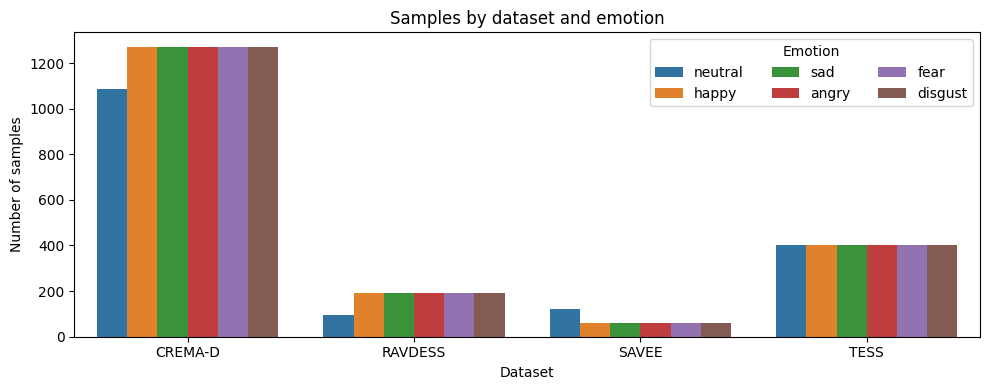

In [5]:
plt.figure(figsize=(10, 4))
sns.countplot(data=metadata, x="dataset", hue="emotion", order=sorted(metadata["dataset"].unique()), hue_order=COMMON_EMOTIONS)
plt.title("Samples by dataset and emotion")
plt.xlabel("Dataset")
plt.ylabel("Number of samples")
plt.legend(title="Emotion", ncol=3)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "samples_by_dataset_emotion.png", dpi=160)
plt.show()


## 5. Unified Feature Engineering

Notebook trích xuất 3 representation từ cùng audio. Cách làm này gọi là **unified feature engineering**: tất cả nhánh nhận cùng một tín hiệu speech đã chuẩn hóa, nhưng mỗi nhánh nhìn tín hiệu đó dưới một dạng khác nhau.

### Branch 1: Temporal sequence features

Theo từng frame:

```text
MFCC 40
+ delta MFCC 40
+ delta-delta MFCC 40
+ RMS 1
+ ZCR 1
+ spectral centroid 1
+ spectral bandwidth 1
+ spectral rolloff 1
+ spectral contrast 7
= 132 features/frame
```

Nhánh này giữ lại trục thời gian, nên model có thể học cách cảm xúc thay đổi trong câu nói: tăng/giảm năng lượng, đổi âm sắc, nhấn giọng, hoặc chuyển trạng thái voiced/unvoiced.

### Branch 2: Pretrained spectrogram representation

Nhánh này dùng log-Mel spectrogram theo chuẩn của audio-pretrained encoder. Về mặt ý tưởng, spectrogram là biểu diễn 2D thời gian-tần số: trục ngang là thời gian, trục dọc là dải tần Mel, giá trị pixel là năng lượng âm thanh. Backbone pretrained đã học pattern audio lớn trước, nên phù hợp khi dataset đồ án không đủ lớn để train deep 2D model từ đầu.

Nếu không tải được checkpoint pretrained, notebook fallback về biểu diễn local:

```text
channel 1: log-Mel spectrogram, 96 bins
channel 2: delta log-Mel
channel 3: delta-delta log-Mel
```

### Branch 3: Statistical vector features

Global statistics over the full clip:

```text
MFCC mean/std/min/max
delta mean/std
delta-delta mean/std
chroma STFT/CQT/CENS mean/std
spectral centroid/bandwidth/rolloff mean/std/max
spectral contrast mean/std
RMS mean/std/max
ZCR mean/std/max
energy mean/std/max
entropy-of-energy mean/std/max
```

Nhánh này không giữ từng frame như branch 1, mà tóm tắt toàn clip thành một vector cố định. Đây là nhóm feature thủ công giống hướng feature engineering trong nhiều baseline truyền thống.


In [6]:
# ============================================================
# 5.1 Audio and feature helpers
# ============================================================
def center_crop_or_pad(y_audio, target_length=TARGET_LENGTH):
    if len(y_audio) > target_length:
        start = (len(y_audio) - target_length) // 2
        y_audio = y_audio[start:start + target_length]
    elif len(y_audio) < target_length:
        pad = target_length - len(y_audio)
        y_audio = np.pad(y_audio, (pad // 2, pad - pad // 2), mode="constant")
    return y_audio.astype(np.float32)


def read_audio(row):
    cached = AUDIO_16K_DIR / f"{row.sample_id}.wav"
    if cached.exists():
        y_audio, sr = sf.read(cached)
        if y_audio.ndim > 1:
            y_audio = y_audio.mean(axis=1)
        if sr != TARGET_SR:
            y_audio = librosa.resample(y_audio.astype(np.float32), orig_sr=sr, target_sr=TARGET_SR)
    else:
        y_audio, sr = librosa.load(row.filepath, sr=TARGET_SR, mono=True)
    y_audio = center_crop_or_pad(y_audio, TARGET_LENGTH)
    peak = np.max(np.abs(y_audio)) + 1e-8
    if peak > 1.0:
        y_audio = y_audio / peak
    return y_audio.astype(np.float32)


def pad_time(x, target, axis=-1):
    if x.shape[axis] > target:
        sl = [slice(None)] * x.ndim
        sl[axis] = slice(0, target)
        return x[tuple(sl)]
    if x.shape[axis] < target:
        pad_width = [(0, 0)] * x.ndim
        pad_width[axis] = (0, target - x.shape[axis])
        return np.pad(x, pad_width, mode="constant")
    return x


def stats_mean_std(x):
    return np.concatenate([x.mean(axis=1), x.std(axis=1)]).astype(np.float32)


def stats_mean_std_min_max(x):
    return np.concatenate([x.mean(axis=1), x.std(axis=1), x.min(axis=1), x.max(axis=1)]).astype(np.float32)


def entropy_of_energy_sequence(y_audio):
    frames = librosa.util.frame(y_audio, frame_length=WIN_LENGTH, hop_length=HOP_LENGTH)
    energy = np.sum(frames ** 2, axis=0).astype(np.float32)
    p = energy / (energy.sum() + 1e-8)
    entropy = -p * np.log2(p + 1e-8)
    return entropy.reshape(1, -1)


In [7]:
# ============================================================
# 5.2 Extract all representations from each audio
# ============================================================
def extract_representations(row):
    y_audio = read_audio(row)

    mfcc = librosa.feature.mfcc(y=y_audio, sr=TARGET_SR, n_mfcc=N_MFCC, n_fft=N_FFT, hop_length=HOP_LENGTH, win_length=WIN_LENGTH)
    delta = librosa.feature.delta(mfcc)
    delta2 = librosa.feature.delta(mfcc, order=2)

    rms = librosa.feature.rms(y=y_audio, frame_length=WIN_LENGTH, hop_length=HOP_LENGTH)
    zcr = librosa.feature.zero_crossing_rate(y_audio, frame_length=WIN_LENGTH, hop_length=HOP_LENGTH)
    centroid = librosa.feature.spectral_centroid(y=y_audio, sr=TARGET_SR, n_fft=N_FFT, hop_length=HOP_LENGTH)
    bandwidth = librosa.feature.spectral_bandwidth(y=y_audio, sr=TARGET_SR, n_fft=N_FFT, hop_length=HOP_LENGTH)
    rolloff = librosa.feature.spectral_rolloff(y=y_audio, sr=TARGET_SR, n_fft=N_FFT, hop_length=HOP_LENGTH)
    contrast = librosa.feature.spectral_contrast(y=y_audio, sr=TARGET_SR, n_fft=N_FFT, hop_length=HOP_LENGTH, n_bands=6)

    temporal = np.concatenate([mfcc, delta, delta2, rms, zcr, centroid, bandwidth, rolloff, contrast], axis=0)
    temporal = pad_time(temporal, MAX_FRAMES, axis=1).T.astype(np.float32)

    mel = librosa.feature.melspectrogram(
        y=y_audio,
        sr=TARGET_SR,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        win_length=WIN_LENGTH,
        n_mels=N_MELS,
        power=2.0,
    )
    logmel = librosa.power_to_db(mel, ref=np.max)
    d_logmel = librosa.feature.delta(logmel)
    d2_logmel = librosa.feature.delta(logmel, order=2)
    spectral = np.stack([
        pad_time(logmel, MAX_FRAMES, axis=1),
        pad_time(d_logmel, MAX_FRAMES, axis=1),
        pad_time(d2_logmel, MAX_FRAMES, axis=1),
    ], axis=0).astype(np.float32)

    chroma_stft = librosa.feature.chroma_stft(y=y_audio, sr=TARGET_SR, n_fft=N_FFT, hop_length=HOP_LENGTH)
    try:
        chroma_cqt = librosa.feature.chroma_cqt(y=y_audio, sr=TARGET_SR, hop_length=HOP_LENGTH)
        chroma_cens = librosa.feature.chroma_cens(y=y_audio, sr=TARGET_SR, hop_length=HOP_LENGTH)
    except Exception:
        chroma_cqt = np.zeros_like(chroma_stft)
        chroma_cens = np.zeros_like(chroma_stft)

    energy = rms ** 2
    entropy = entropy_of_energy_sequence(y_audio)
    stat_vec = np.concatenate([
        stats_mean_std_min_max(mfcc),
        stats_mean_std(delta),
        stats_mean_std(delta2),
        stats_mean_std(chroma_stft),
        stats_mean_std(chroma_cqt),
        stats_mean_std(chroma_cens),
        np.array([centroid.mean(), centroid.std(), centroid.max()], dtype=np.float32),
        np.array([bandwidth.mean(), bandwidth.std(), bandwidth.max()], dtype=np.float32),
        np.array([rolloff.mean(), rolloff.std(), rolloff.max()], dtype=np.float32),
        stats_mean_std(contrast),
        np.array([rms.mean(), rms.std(), rms.max()], dtype=np.float32),
        np.array([zcr.mean(), zcr.std(), zcr.max()], dtype=np.float32),
        np.array([energy.mean(), energy.std(), energy.max()], dtype=np.float32),
        np.array([entropy.mean(), entropy.std(), entropy.max()], dtype=np.float32),
    ]).astype(np.float32)
    stat_vec = np.nan_to_num(stat_vec, nan=0.0, posinf=0.0, neginf=0.0)
    return temporal, spectral, stat_vec


cache_path = CACHE_DIR / f"multi_rep_features_{int(TARGET_DURATION)}s_{TARGET_SR}hz_{len(metadata)}files.npz"
if CACHE_FEATURES and cache_path.exists():
    data = np.load(cache_path)
    X_temporal = data["X_temporal"]
    X_spectral = data["X_spectral"]
    X_stats = data["X_stats"]
    y = data["y"]
    print("Loaded feature cache:", cache_path)
else:
    X_temporal, X_spectral, X_stats = [], [], []
    start = time.time()
    for i, row in enumerate(metadata.itertuples(index=False)):
        a, b, c = extract_representations(row)
        X_temporal.append(a)
        X_spectral.append(b)
        X_stats.append(c)
        if (i + 1) % 500 == 0:
            print(f"Extracted {i+1}/{len(metadata)} files in {(time.time()-start)/60:.1f} min")
    X_temporal = np.stack(X_temporal).astype(np.float32)
    X_spectral = np.stack(X_spectral).astype(np.float32)
    X_stats = np.stack(X_stats).astype(np.float32)
    y = metadata["label_id"].to_numpy(np.int64)
    if CACHE_FEATURES:
        np.savez_compressed(cache_path, X_temporal=X_temporal, X_spectral=X_spectral, X_stats=X_stats, y=y)
        print("Saved feature cache:", cache_path)

TEMPORAL_DIM = X_temporal.shape[-1]
STATS_DIM = X_stats.shape[-1]
print("X_temporal:", X_temporal.shape)
print("X_spectral:", X_spectral.shape)
print("X_stats:", X_stats.shape)
print("y:", y.shape)


Extracted 500/11317 files in 2.5 min
Extracted 1000/11317 files in 4.7 min
Extracted 1500/11317 files in 6.9 min
Extracted 2000/11317 files in 9.3 min
Extracted 2500/11317 files in 11.6 min
Extracted 3000/11317 files in 13.8 min
Extracted 3500/11317 files in 16.1 min
Extracted 4000/11317 files in 18.3 min
Extracted 4500/11317 files in 20.6 min
Extracted 5000/11317 files in 22.9 min
Extracted 5500/11317 files in 25.2 min
Extracted 6000/11317 files in 27.4 min
Extracted 6500/11317 files in 29.7 min
Extracted 7000/11317 files in 31.9 min
Extracted 7500/11317 files in 34.2 min
Extracted 8000/11317 files in 36.5 min
Extracted 8500/11317 files in 38.7 min
Extracted 9000/11317 files in 41.0 min
Extracted 9500/11317 files in 43.3 min
Extracted 10000/11317 files in 45.6 min
Extracted 10500/11317 files in 48.0 min
Extracted 11000/11317 files in 50.2 min
Saved feature cache: /kaggle/working/05_Multi_Representation_Ensemble_outputs/cache/multi_rep_features_3s_16000hz_11317files.npz
X_temporal: (11

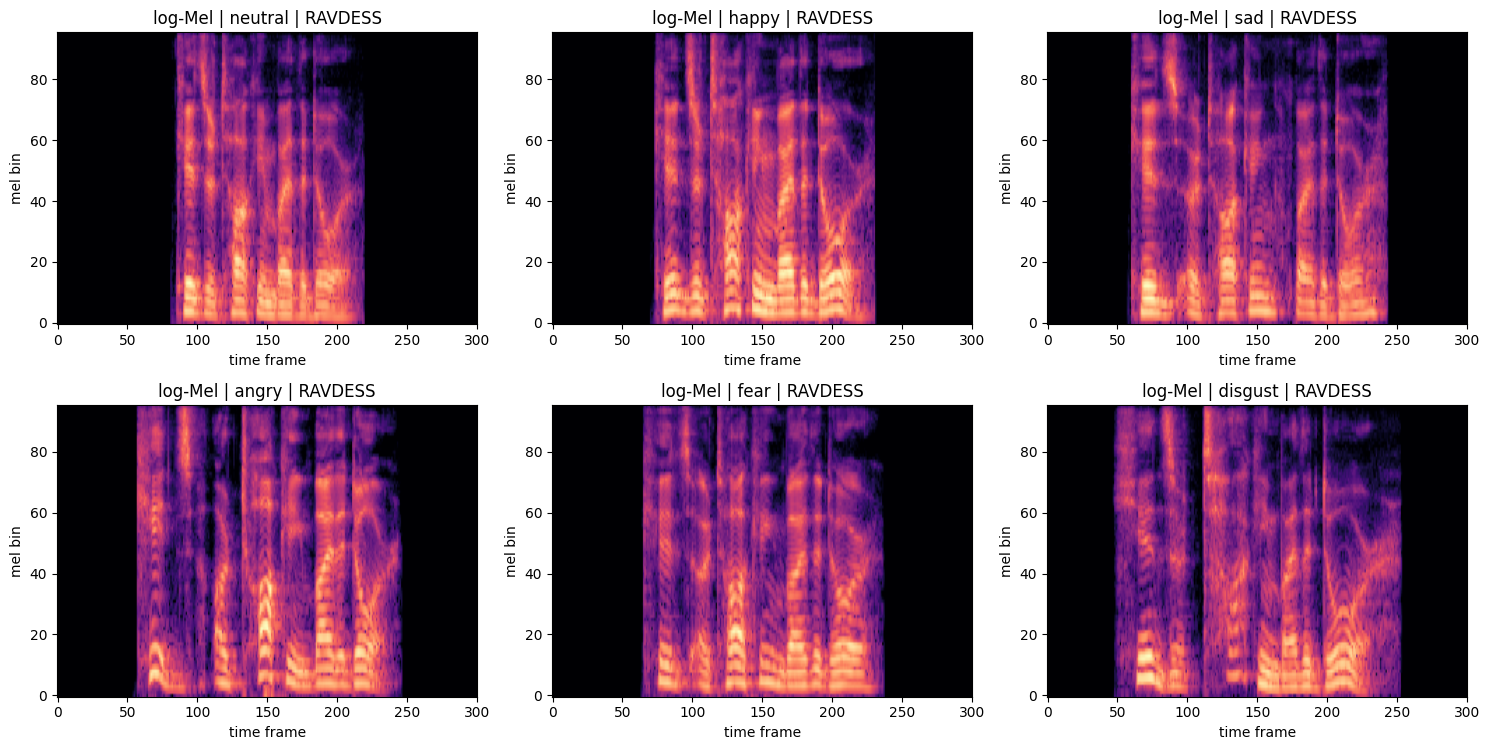

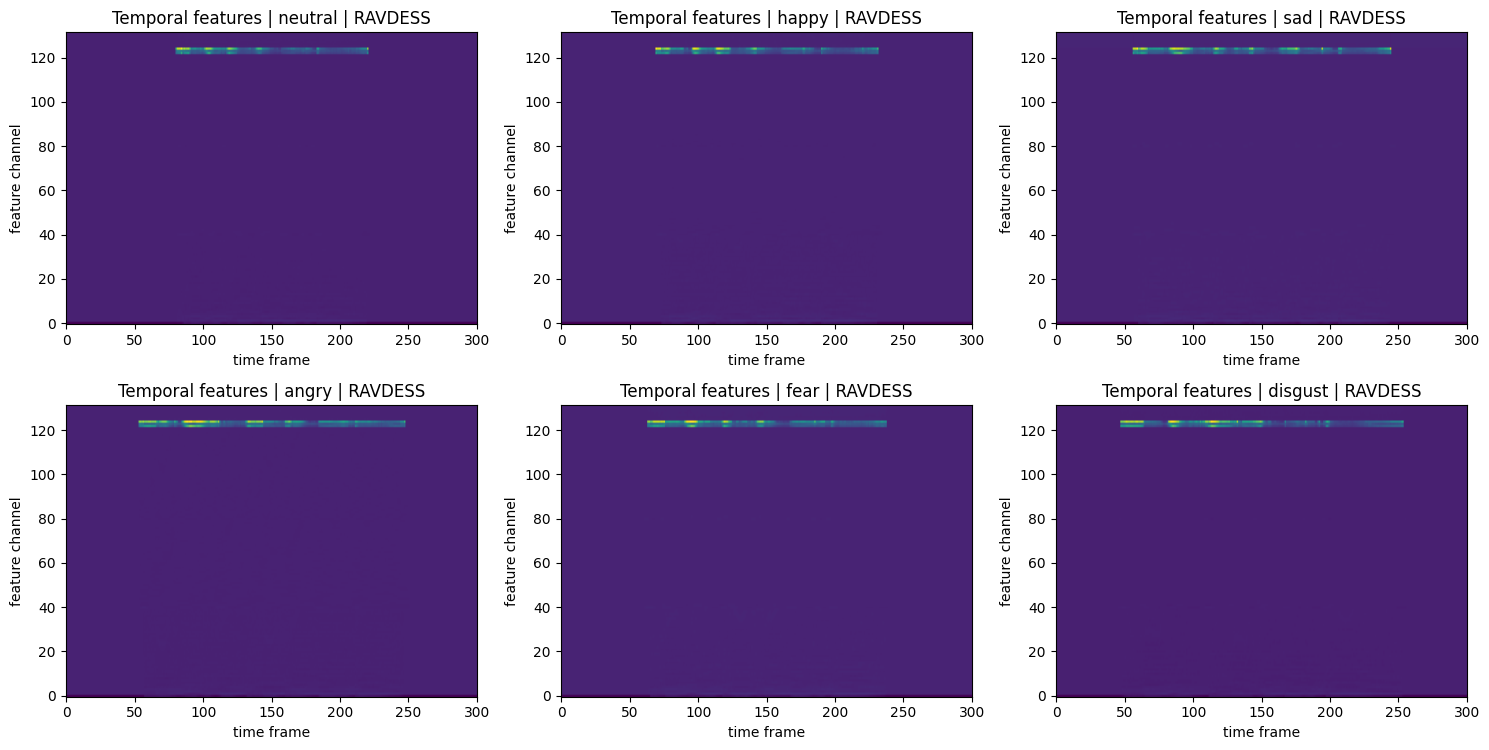

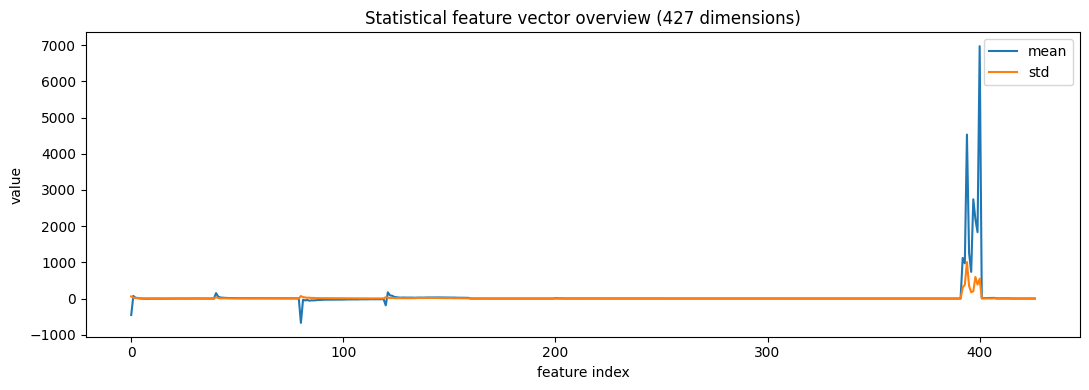

In [8]:
# Feature visualizations
sample_indices = []
for emotion in COMMON_EMOTIONS:
    idx = metadata.index[metadata["emotion"].eq(emotion)]
    if len(idx):
        sample_indices.append(idx[0])

cols = min(3, len(sample_indices))
rows = int(np.ceil(len(sample_indices) / cols))

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 3.8 * rows))
axes = np.array(axes).reshape(-1)
for ax, idx in zip(axes, sample_indices):
    ax.imshow(X_spectral[idx, 0], aspect="auto", origin="lower", cmap="magma")
    ax.set_title(f"log-Mel | {metadata.loc[idx, 'emotion']} | {metadata.loc[idx, 'dataset']}")
    ax.set_xlabel("time frame")
    ax.set_ylabel("mel bin")
for ax in axes[len(sample_indices):]:
    ax.axis("off")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "logmel_examples_by_emotion.png", dpi=160)
plt.show()

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 3.8 * rows))
axes = np.array(axes).reshape(-1)
for ax, idx in zip(axes, sample_indices):
    ax.imshow(X_temporal[idx].T, aspect="auto", origin="lower", cmap="viridis")
    ax.set_title(f"Temporal features | {metadata.loc[idx, 'emotion']} | {metadata.loc[idx, 'dataset']}")
    ax.set_xlabel("time frame")
    ax.set_ylabel("feature channel")
for ax in axes[len(sample_indices):]:
    ax.axis("off")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "temporal_feature_examples_by_emotion.png", dpi=160)
plt.show()

plt.figure(figsize=(11, 4))
plt.plot(X_stats.mean(axis=0), label="mean")
plt.plot(X_stats.std(axis=0), label="std")
plt.title(f"Statistical feature vector overview ({STATS_DIM} dimensions)")
plt.xlabel("feature index")
plt.ylabel("value")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "statistical_feature_vector_overview.png", dpi=160)
plt.show()


In [9]:
# ============================================================
# 5.3 Branch 2 pretrained spectrogram embeddings
# ============================================================
# This cell uses an audio-pretrained spectrogram encoder when possible.
# The notebook names the architecture as a 3-branch ensemble; the concrete default
# checkpoint is kept configurable for reproducibility.
X_spectral_pretrained = None
SPECTRAL_BRANCH_MODE = "cnn_fallback"
SPECTRAL_BRANCH_NAME = "spectral_2d_se_cnn"

if SPECTRAL_BACKBONE == "pretrained":
    pretrained_cache = CACHE_DIR / f"spectral_pretrained_{SPECTRAL_PRETRAINED_MODEL.replace('/', '_')}_{len(metadata)}files.npz"
    if CACHE_FEATURES and pretrained_cache.exists():
        data = np.load(pretrained_cache)
        X_spectral_pretrained = data["X_spectral_pretrained"].astype(np.float32)
        SPECTRAL_BRANCH_MODE = "pretrained"
        SPECTRAL_BRANCH_NAME = "spectral_pretrained_branch"
        print("Loaded pretrained spectrogram embeddings:", pretrained_cache, X_spectral_pretrained.shape)
    else:
        try:
            from transformers import ASTFeatureExtractor, ASTModel

            feature_extractor = ASTFeatureExtractor.from_pretrained(SPECTRAL_PRETRAINED_MODEL)
            pretrained_encoder = ASTModel.from_pretrained(SPECTRAL_PRETRAINED_MODEL).to(DEVICE)
            pretrained_encoder.eval()
            embeddings = []
            start = time.time()
            with torch.no_grad():
                rows = list(metadata.itertuples(index=False))
                for start_idx in range(0, len(rows), SPECTRAL_EMBED_BATCH_SIZE):
                    batch_rows = rows[start_idx:start_idx + SPECTRAL_EMBED_BATCH_SIZE]
                    waves = [read_audio(row) for row in batch_rows]
                    inputs = feature_extractor(waves, sampling_rate=TARGET_SR, return_tensors="pt", padding=True)
                    inputs = {k: v.to(DEVICE) for k, v in inputs.items()}
                    out = pretrained_encoder(**inputs)
                    if getattr(out, "pooler_output", None) is not None:
                        emb = out.pooler_output
                    else:
                        emb = out.last_hidden_state.mean(dim=1)
                    embeddings.append(emb.detach().cpu().numpy().astype(np.float32))
                    done = min(start_idx + len(batch_rows), len(rows))
                    if done % 240 == 0 or done == len(rows):
                        print(f"Pretrained spectral embeddings {done}/{len(rows)} in {(time.time()-start)/60:.1f} min")
            X_spectral_pretrained = np.concatenate(embeddings, axis=0).astype(np.float32)
            SPECTRAL_BRANCH_MODE = "pretrained"
            SPECTRAL_BRANCH_NAME = "spectral_pretrained_branch"
            if CACHE_FEATURES:
                np.savez_compressed(pretrained_cache, X_spectral_pretrained=X_spectral_pretrained)
                print("Saved pretrained spectrogram embeddings:", pretrained_cache)
        except Exception as e:
            print("Could not load/use pretrained spectrogram encoder. Falling back to local 2D-CNN branch.")
            print(type(e).__name__, str(e)[:500])
            X_spectral_pretrained = None
            SPECTRAL_BRANCH_MODE = "cnn_fallback"
            SPECTRAL_BRANCH_NAME = "spectral_2d_se_cnn"

print("SPECTRAL_BRANCH_MODE:", SPECTRAL_BRANCH_MODE)
print("SPECTRAL_BRANCH_NAME:", SPECTRAL_BRANCH_NAME)
if X_spectral_pretrained is not None:
    print("X_spectral_pretrained:", X_spectral_pretrained.shape)


preprocessor_config.json:   0%|          | 0.00/297 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

ASTModel LOAD REPORT from: MIT/ast-finetuned-audioset-10-10-0.4593
Key                         | Status     |  | 
----------------------------+------------+--+-
classifier.layernorm.bias   | UNEXPECTED |  | 
classifier.layernorm.weight | UNEXPECTED |  | 
classifier.dense.bias       | UNEXPECTED |  | 
classifier.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Pretrained spectral embeddings 240/11317 in 0.3 min
Pretrained spectral embeddings 480/11317 in 0.7 min
Pretrained spectral embeddings 720/11317 in 1.0 min
Pretrained spectral embeddings 960/11317 in 1.4 min
Pretrained spectral embeddings 1200/11317 in 1.7 min
Pretrained spectral embeddings 1440/11317 in 2.1 min
Pretrained spectral embeddings 1680/11317 in 2.5 min
Pretrained spectral embeddings 1920/11317 in 2.9 min
Pretrained spectral embeddings 2160/11317 in 3.3 min
Pretrained spectral embeddings 2400/11317 in 3.7 min
Pretrained spectral embeddings 2640/11317 in 4.1 min
Pretrained spectral embeddings 2880/11317 in 4.5 min
Pretrained spectral embeddings 3120/11317 in 4.9 min
Pretrained spectral embeddings 3360/11317 in 5.3 min
Pretrained spectral embeddings 3600/11317 in 5.7 min
Pretrained spectral embeddings 3840/11317 in 6.1 min
Pretrained spectral embeddings 4080/11317 in 6.5 min
Pretrained spectral embeddings 4320/11317 in 6.9 min
Pretrained spectral embeddings 4560/11317 in 7.3 m

## 6. Datasets and Augmentation

Augmentation chỉ áp dụng cho deep models trên train set:

- time shift;
- Gaussian noise nhẹ;
- time masking;
- frequency masking trên spectral image;
- mixup trong training loop.

RBF-SVM dùng statistical vector gốc đã scale theo train set, không augment để giữ pipeline ổn định và nhanh.


In [10]:
# ============================================================
# 6. Dataset classes
# ============================================================
def compute_deep_scalers(train_idx):
    temporal_mean = X_temporal[train_idx].mean(axis=(0, 1), keepdims=True)
    temporal_std = X_temporal[train_idx].std(axis=(0, 1), keepdims=True) + 1e-6
    spectral_mean = X_spectral[train_idx].mean(axis=(0, 2, 3), keepdims=True)
    spectral_std = X_spectral[train_idx].std(axis=(0, 2, 3), keepdims=True) + 1e-6
    pretrained_scaler = None
    if X_spectral_pretrained is not None:
        pretrained_scaler = StandardScaler().fit(X_spectral_pretrained[train_idx])
    return temporal_mean.astype(np.float32), temporal_std.astype(np.float32), spectral_mean.astype(np.float32), spectral_std.astype(np.float32), pretrained_scaler


def augment_temporal(x):
    if not USE_AUGMENTATION:
        return x
    if random.random() < 0.35:
        x = np.roll(x, random.randint(-16, 16), axis=0)
    if random.random() < 0.35:
        x = x + np.random.normal(0, 0.02, x.shape).astype(np.float32)
    if random.random() < 0.45:
        width = random.randint(8, 32)
        start = random.randint(0, max(0, x.shape[0] - width))
        x[start:start + width, :] = 0
    return x


def augment_spectral(x):
    if not USE_AUGMENTATION:
        return x
    if random.random() < 0.35:
        x = np.roll(x, random.randint(-16, 16), axis=2)
    if random.random() < 0.35:
        x = x + np.random.normal(0, 0.02, x.shape).astype(np.float32)
    if random.random() < 0.45:
        width = random.randint(8, 32)
        start = random.randint(0, max(0, x.shape[2] - width))
        x[:, :, start:start + width] = 0
    if random.random() < 0.45:
        width = random.randint(6, 18)
        start = random.randint(0, max(0, x.shape[1] - width))
        x[:, start:start + width, :] = 0
    return x


class TemporalDataset(Dataset):
    def __init__(self, indices, scalers, train=False):
        self.indices = np.array(indices)
        self.mean, self.std, _, _, _ = scalers
        self.train = train

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        i = self.indices[idx]
        x = ((X_temporal[i] - self.mean.squeeze(0)) / self.std.squeeze(0)).astype(np.float32)
        if self.train:
            x = augment_temporal(x.copy())
        return torch.from_numpy(x.T), torch.tensor(y[i], dtype=torch.long)


class SpectralDataset(Dataset):
    def __init__(self, indices, scalers, train=False):
        self.indices = np.array(indices)
        _, _, self.mean, self.std, _ = scalers
        self.train = train

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        i = self.indices[idx]
        x = ((X_spectral[i] - self.mean.squeeze(0)) / self.std.squeeze(0)).astype(np.float32)
        if self.train:
            x = augment_spectral(x.copy())
        return torch.from_numpy(x), torch.tensor(y[i], dtype=torch.long)


class SpectralPretrainedDataset(Dataset):
    def __init__(self, indices, scalers, train=False):
        self.indices = np.array(indices)
        self.scaler = scalers[-1]
        self.train = train

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        i = self.indices[idx]
        x = self.scaler.transform(X_spectral_pretrained[i:i + 1]).astype(np.float32)[0]
        if self.train and USE_AUGMENTATION and random.random() < 0.25:
            x = x + np.random.normal(0, 0.015, x.shape).astype(np.float32)
        return torch.from_numpy(x), torch.tensor(y[i], dtype=torch.long)


def make_deep_loaders(split_map, model_type):
    scalers = compute_deep_scalers(split_map["train"])
    if model_type == "temporal":
        ds_cls = TemporalDataset
    elif model_type == "spectral_pretrained":
        ds_cls = SpectralPretrainedDataset
    else:
        ds_cls = SpectralDataset
    loaders = {
        "train": DataLoader(ds_cls(split_map["train"], scalers, train=True), batch_size=BATCH_SIZE, shuffle=True, num_workers=0),
        "validation": DataLoader(ds_cls(split_map["validation"], scalers, train=False), batch_size=BATCH_SIZE, shuffle=False, num_workers=0),
        "test": DataLoader(ds_cls(split_map["test"], scalers, train=False), batch_size=BATCH_SIZE, shuffle=False, num_workers=0),
    }
    return loaders, scalers


## 7. Model Definitions

### Branch 1: Temporal acoustic model

`1D-CNN + BiGRU + attention pooling` nhận chuỗi feature theo thời gian. 1D-CNN học local acoustic pattern trước, ví dụ đoạn năng lượng tăng nhanh hoặc spectral contrast thay đổi. BiGRU đọc chuỗi theo hai chiều thời gian để lấy ngữ cảnh trước/sau mỗi frame. Attention pooling học frame nào quan trọng hơn cho cảm xúc, thay vì xem mọi frame đều có trọng số như nhau.

### Branch 2: Pretrained spectrogram model

Nhánh này ưu tiên dùng encoder spectrogram đã pretrained trên audio lớn, sau đó train một classifier head nhỏ cho 6 emotion. Nếu môi trường không có checkpoint, notebook dùng fallback `2D-CNN + SE attention` trên ảnh log-Mel 3 kênh. SE attention là cơ chế học kênh/feature map nào quan trọng hơn trong spectrogram.

### Branch 3: Statistical acoustic model

`RBF-SVM` dùng vector thống kê toàn clip. Đây là model phù hợp với feature vector cố định và đã mạnh trong baseline 04. RBF kernel giúp SVM tạo ranh giới phi tuyến, nên linh hoạt hơn linear SVM khi cảm xúc không tách tuyến tính trong không gian feature.

### Final ensemble

Ba nhánh tạo ra xác suất dự đoán riêng cho 6 emotion. Kết quả cuối cùng là weighted ensemble theo validation macro-F1: nhánh nào validation tốt hơn thì có trọng số lớn hơn. Cách này khác gated fusion ở chỗ các model học độc lập trước, sau đó mới kết hợp xác suất, nên nhánh yếu ít kéo hỏng embedding của nhánh mạnh.


In [11]:
# ============================================================
# 7. Model definitions
# ============================================================
class SE1D(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        hidden = max(8, channels // reduction)
        self.net = nn.Sequential(nn.AdaptiveAvgPool1d(1), nn.Flatten(), nn.Linear(channels, hidden), nn.GELU(), nn.Linear(hidden, channels), nn.Sigmoid())

    def forward(self, x):
        return x * self.net(x).unsqueeze(-1)


class SE2D(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        hidden = max(8, channels // reduction)
        self.net = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Linear(channels, hidden), nn.GELU(), nn.Linear(hidden, channels), nn.Sigmoid())

    def forward(self, x):
        return x * self.net(x).view(x.size(0), x.size(1), 1, 1)


class AttentionPool1D(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.attn = nn.Sequential(nn.Linear(channels, max(16, channels // 2)), nn.Tanh(), nn.Linear(max(16, channels // 2), 1))

    def forward(self, x):
        w = torch.softmax(self.attn(x), dim=1)
        return (x * w).sum(dim=1)


class TemporalCNNBiGRUAttention(nn.Module):
    def __init__(self, in_channels, num_classes, hidden=128):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(in_channels, 96, 5, padding=2),
            nn.BatchNorm1d(96),
            nn.GELU(),
            nn.Dropout(DROPOUT),
            nn.Conv1d(96, 128, 5, padding=4, dilation=2),
            nn.BatchNorm1d(128),
            nn.GELU(),
            SE1D(128),
            nn.MaxPool1d(2),
            nn.Conv1d(128, 192, 5, padding=6, dilation=3),
            nn.BatchNorm1d(192),
            nn.GELU(),
            nn.Dropout(DROPOUT),
            nn.MaxPool1d(2),
        )
        self.gru = nn.GRU(192, hidden, batch_first=True, bidirectional=True)
        self.pool = AttentionPool1D(hidden * 2)
        self.cls = nn.Sequential(
            nn.LayerNorm(hidden * 2),
            nn.Dropout(DROPOUT),
            nn.Linear(hidden * 2, 128),
            nn.GELU(),
            nn.Dropout(DROPOUT),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.cnn(x).transpose(1, 2)
        out, _ = self.gru(x.contiguous())
        return self.cls(self.pool(out))


class SpectralSE2DCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        def block(i, o):
            return nn.Sequential(
                nn.Conv2d(i, o, 3, padding=1),
                nn.BatchNorm2d(o),
                nn.GELU(),
                nn.Conv2d(o, o, 3, padding=1),
                nn.BatchNorm2d(o),
                nn.GELU(),
                SE2D(o),
                nn.MaxPool2d(2),
                nn.Dropout2d(0.12),
            )

        self.cnn = nn.Sequential(block(3, 32), block(32, 64), block(64, 128), block(128, 160))
        self.cls = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(160, 192),
            nn.LayerNorm(192),
            nn.GELU(),
            nn.Dropout(DROPOUT),
            nn.Linear(192, 128),
            nn.GELU(),
            nn.Dropout(DROPOUT),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.cls(self.cnn(x))


class SpectralPretrainedMLP(nn.Module):
    def __init__(self, in_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Dropout(DROPOUT),
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Dropout(DROPOUT),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.net(x)


def build_deep_model(model_type):
    if model_type == "temporal":
        return TemporalCNNBiGRUAttention(TEMPORAL_DIM, len(COMMON_EMOTIONS)).to(DEVICE)
    if model_type == "spectral_pretrained":
        return SpectralPretrainedMLP(X_spectral_pretrained.shape[1], len(COMMON_EMOTIONS)).to(DEVICE)
    if model_type == "spectral":
        return SpectralSE2DCNN(len(COMMON_EMOTIONS)).to(DEVICE)
    raise ValueError(model_type)


preview_model_types = ["temporal", "spectral_pretrained" if X_spectral_pretrained is not None else "spectral"]
for model_type in preview_model_types:
    m = build_deep_model(model_type)
    print(model_type, "parameters:", sum(p.numel() for p in m.parameters()))
    del m
torch.cuda.empty_cache()


temporal parameters: 567671
spectral_pretrained parameters: 231046


In [12]:
# ============================================================
# 8. Training helpers
# ============================================================
def class_weights_for(indices):
    counts = np.bincount(y[indices], minlength=len(COMMON_EMOTIONS)).astype(np.float32)
    weights = counts.sum() / (len(COMMON_EMOTIONS) * np.maximum(counts, 1))
    weights = weights / weights.mean()
    return torch.tensor(weights, dtype=torch.float32, device=DEVICE)


def maybe_mixup(x, target):
    if (not USE_AUGMENTATION) or MIXUP_ALPHA <= 0 or random.random() > MIXUP_PROB:
        return x, target, None, 1.0
    lam = np.random.beta(MIXUP_ALPHA, MIXUP_ALPHA)
    perm = torch.randperm(x.size(0), device=x.device)
    return lam * x + (1 - lam) * x[perm], target, target[perm], lam


def run_deep_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)
    total_loss, all_y, all_pred, all_prob = 0.0, [], [], []
    for x, target in loader:
        x, target = x.to(DEVICE), target.to(DEVICE)
        if is_train:
            optimizer.zero_grad(set_to_none=True)
            x_in, target_a, target_b, lam = maybe_mixup(x, target)
        else:
            x_in, target_a, target_b, lam = x, target, None, 1.0

        with torch.set_grad_enabled(is_train):
            logits = model(x_in)
            if is_train and target_b is not None:
                loss = lam * criterion(logits, target_a) + (1 - lam) * criterion(logits, target_b)
            else:
                loss = criterion(logits, target)
            if is_train:
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 5.0)
                optimizer.step()

        with torch.no_grad():
            eval_logits = model(x) if is_train and target_b is not None else logits
            prob = torch.softmax(eval_logits.detach(), dim=1)
        total_loss += loss.item() * len(target)
        all_y.extend(target.detach().cpu().numpy())
        all_pred.extend(prob.argmax(dim=1).cpu().numpy())
        all_prob.extend(prob.cpu().numpy())

    all_y = np.array(all_y)
    all_pred = np.array(all_pred)
    all_prob = np.array(all_prob)
    return {
        "loss": total_loss / max(1, len(all_y)),
        "accuracy": accuracy_score(all_y, all_pred),
        "macro_f1": f1_score(all_y, all_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(all_y, all_pred, average="weighted", zero_division=0),
        "macro_precision": precision_score(all_y, all_pred, average="macro", zero_division=0),
        "macro_recall": recall_score(all_y, all_pred, average="macro", zero_division=0),
        "y_true": all_y,
        "y_pred": all_pred,
        "prob": all_prob,
    }


def evaluate_prob(y_true, prob):
    y_pred = prob.argmax(axis=1)
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "macro_precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "y_true": y_true,
        "y_pred": y_pred,
        "prob": prob,
    }


def plot_confusion(y_true, y_pred, title, path):
    cm = confusion_matrix(y_true, y_pred, labels=list(range(len(COMMON_EMOTIONS))))
    plt.figure(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=COMMON_EMOTIONS, yticklabels=COMMON_EMOTIONS)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.savefig(path, dpi=160)
    plt.close()


In [13]:
def train_deep_model(run_name, model_type, split_map):
    component_type = "temporal" if model_type.startswith("temporal") else ("spectral_pretrained" if model_type.startswith("spectral_pretrained") else "spectral")
    loaders, scalers = make_deep_loaders(split_map, component_type)
    model = build_deep_model(component_type)
    weights = class_weights_for(split_map["train"]) if USE_CLASS_WEIGHTS else None
    criterion = nn.CrossEntropyLoss(weight=weights, label_smoothing=LABEL_SMOOTHING)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=3)

    best_state, best_val, best_epoch, stale = None, -1.0, 0, 0
    history = []
    start = time.time()
    for epoch in range(1, MAX_EPOCHS + 1):
        tr = run_deep_epoch(model, loaders["train"], criterion, optimizer)
        va = run_deep_epoch(model, loaders["validation"], criterion, None)
        scheduler.step(va["macro_f1"])
        row = {
            "run_name": run_name,
            "model": model_type,
            "epoch": epoch,
            "train_loss": tr["loss"],
            "train_macro_f1": tr["macro_f1"],
            "val_loss": va["loss"],
            "val_macro_f1": va["macro_f1"],
            "val_accuracy": va["accuracy"],
            "lr": optimizer.param_groups[0]["lr"],
        }
        history.append(row)
        print(f"{run_name} | {model_type} | epoch {epoch:02d} | train f1 {tr['macro_f1']:.4f} | val f1 {va['macro_f1']:.4f}")
        if va["macro_f1"] > best_val:
            best_val, best_epoch, stale = va["macro_f1"], epoch, 0
            best_state = {k: v.detach().cpu() for k, v in model.state_dict().items()}
        else:
            stale += 1
            if stale >= PATIENCE:
                print("Early stopping.")
                break

    model.load_state_dict(best_state)
    t0 = time.time()
    val_eval = run_deep_epoch(model, loaders["validation"], criterion, None)
    test_eval = run_deep_epoch(model, loaders["test"], criterion, None)
    inference_time = time.time() - t0

    torch.save(
        {
            "model_state": best_state,
            "model_type": model_type,
            "run_name": run_name,
            "best_epoch": best_epoch,
            "config": {
                "TEMPORAL_DIM": TEMPORAL_DIM,
                "STATS_DIM": STATS_DIM,
                "N_MELS": N_MELS,
                "TARGET_DURATION": TARGET_DURATION,
                "COMMON_EMOTIONS": COMMON_EMOTIONS,
            },
        },
        MODEL_DIR / f"{run_name}_{model_type}.pt",
    )

    metric = {
        "run_name": run_name,
        "model": model_type,
        "split": "test",
        "n_samples": len(test_eval["y_true"]),
        "accuracy": test_eval["accuracy"],
        "macro_f1": test_eval["macro_f1"],
        "weighted_f1": test_eval["weighted_f1"],
        "macro_precision": test_eval["macro_precision"],
        "macro_recall": test_eval["macro_recall"],
        "best_epoch": best_epoch,
        "best_val_macro_f1": best_val,
        "train_time_sec": time.time() - start,
        "inference_time_sec": inference_time,
        "inference_ms_per_sample": 1000 * inference_time / max(1, len(test_eval["y_true"])),
    }
    return metric, history, val_eval["prob"], test_eval["prob"]


def train_stats_svm(run_name, split_map):
    start = time.time()
    clf = make_pipeline(
        StandardScaler(),
        SVC(kernel="rbf", C=10.0, gamma="scale", probability=True, class_weight="balanced", random_state=SEED),
    )
    clf.fit(X_stats[split_map["train"]], y[split_map["train"]])
    val_prob = clf.predict_proba(X_stats[split_map["validation"]])
    test_prob = clf.predict_proba(X_stats[split_map["test"]])
    val_eval = evaluate_prob(y[split_map["validation"]], val_prob)
    test_eval = evaluate_prob(y[split_map["test"]], test_prob)
    import joblib
    joblib.dump(clf, MODEL_DIR / f"{run_name}_stats_rbf_svm.joblib")
    metric = {
        "run_name": run_name,
        "model": "stats_rbf_svm",
        "split": "test",
        "n_samples": len(test_eval["y_true"]),
        "accuracy": test_eval["accuracy"],
        "macro_f1": test_eval["macro_f1"],
        "weighted_f1": test_eval["weighted_f1"],
        "macro_precision": test_eval["macro_precision"],
        "macro_recall": test_eval["macro_recall"],
        "best_epoch": 0,
        "best_val_macro_f1": val_eval["macro_f1"],
        "train_time_sec": time.time() - start,
        "inference_time_sec": 0.0,
        "inference_ms_per_sample": 0.0,
    }
    print(f"{run_name} | stats_rbf_svm | val f1 {val_eval['macro_f1']:.4f} | test f1 {test_eval['macro_f1']:.4f}")
    return metric, [], val_prob, test_prob


In [14]:
# ============================================================
# 9. Split builders
# ============================================================
def split_from_column(col, include_mask=None):
    df = metadata if include_mask is None else metadata[include_mask]
    split_values = df[col].to_numpy()
    indices = df.index.to_numpy()
    out = {s: indices[split_values == s] for s in ["train", "validation", "test"]}
    if len(out["validation"]) == 0 and len(out["train"]) > 10:
        train_sub, val_sub = train_test_split(out["train"], test_size=0.12, random_state=SEED, stratify=y[out["train"]])
        out["train"], out["validation"] = train_sub, val_sub
    return out


experiments = []
if RUN_COMBINED_RANDOM:
    experiments.append(("combined_random", split_from_column("split_random")))
if RUN_COMBINED_STRICT:
    strict_mask = metadata["split_strict_project"].isin(["train", "validation", "test"])
    experiments.append(("combined_strict_no_tess", split_from_column("split_strict_project", strict_mask)))
if RUN_SINGLE_DATASET:
    for ds in sorted(metadata["dataset"].unique()):
        ds_df = metadata[metadata["dataset"].eq(ds)]
        idx_train, idx_temp = train_test_split(ds_df.index, test_size=0.30, random_state=SEED, stratify=metadata.loc[ds_df.index, "label_id"])
        idx_val, idx_test = train_test_split(idx_temp, test_size=0.50, random_state=SEED, stratify=metadata.loc[idx_temp, "label_id"])
        experiments.append((f"single_{ds}", {"train": np.array(idx_train), "validation": np.array(idx_val), "test": np.array(idx_test)}))

for name, split_map in experiments:
    print(name, {k: len(v) for k, v in split_map.items()})


combined_random {'train': 7921, 'validation': 1698, 'test': 1698}
combined_strict_no_tess {'train': 6110, 'validation': 854, 'test': 1953}
single_CREMA-D {'train': 5208, 'validation': 1116, 'test': 1117}
single_RAVDESS {'train': 739, 'validation': 158, 'test': 159}
single_SAVEE {'train': 294, 'validation': 63, 'test': 63}
single_TESS {'train': 1680, 'validation': 360, 'test': 360}


## 10. Train Individual Models and Ensemble

Ensemble weight được tính từ validation macro-F1:

```text
w_i = val_macro_f1_i / sum(val_macro_f1_all)
final_prob = sum(w_i * prob_i)
```

Nếu một model yếu ở validation, nó tự nhận weight thấp hơn.


In [15]:
# ============================================================
# 10. Train and evaluate
# ============================================================
all_metrics, all_history, all_per_dataset, all_weights = [], [], [], []


def collect_per_dataset(run_name, model_name, split_map, prob):
    eval_out = evaluate_prob(y[split_map["test"]], prob)
    pred_df = metadata.loc[split_map["test"], ["sample_id", "dataset", "speaker_id", "emotion"]].copy()
    pred_df["y_true"] = eval_out["y_true"]
    pred_df["y_pred"] = eval_out["y_pred"]
    pred_df["pred_emotion"] = [ID_TO_LABEL[i] for i in eval_out["y_pred"]]
    for i, label in ID_TO_LABEL.items():
        pred_df[f"prob_{label}"] = eval_out["prob"][:, i]
    pred_df.to_csv(PRED_DIR / f"predictions_{run_name}_{model_name}.csv", index=False)
    plot_confusion(eval_out["y_true"], eval_out["y_pred"], f"{run_name} {model_name}", FIGURE_DIR / f"confusion_matrix_{run_name}_{model_name}.png")

    report = classification_report(eval_out["y_true"], eval_out["y_pred"], labels=list(range(len(COMMON_EMOTIONS))), target_names=COMMON_EMOTIONS, output_dict=True, zero_division=0)
    per_class = pd.DataFrame(report).T.reset_index().rename(columns={"index": "class"})
    per_class.insert(0, "model", model_name)
    per_class.insert(0, "run_name", run_name)
    per_class.to_csv(REPORT_DIR / f"per_class_{run_name}_{model_name}.csv", index=False)

    rows = []
    for ds, part in pred_df.groupby("dataset"):
        rows.append({
            "run_name": run_name,
            "model": model_name,
            "dataset": ds,
            "n_samples": len(part),
            "accuracy": accuracy_score(part["y_true"], part["y_pred"]),
            "macro_f1": f1_score(part["y_true"], part["y_pred"], average="macro", zero_division=0),
        })
    return rows


for run_name, split_map in experiments:
    print("\n" + "=" * 90)
    print("EXPERIMENT:", run_name)
    model_outputs = {}

    if RUN_TEMPORAL:
        metric, history, val_prob, test_prob = train_deep_model(run_name, "temporal_cnn_bigru_attention", split_map)
        all_metrics.append(metric)
        all_history.extend(history)
        model_outputs["temporal_cnn_bigru_attention"] = {"metric": metric, "val_prob": val_prob, "test_prob": test_prob}
        all_per_dataset.extend(collect_per_dataset(run_name, "temporal_cnn_bigru_attention", split_map, test_prob))

    if RUN_SPECTRAL:
        metric, history, val_prob, test_prob = train_deep_model(run_name, SPECTRAL_BRANCH_NAME, split_map)
        all_metrics.append(metric)
        all_history.extend(history)
        model_outputs[SPECTRAL_BRANCH_NAME] = {"metric": metric, "val_prob": val_prob, "test_prob": test_prob}
        all_per_dataset.extend(collect_per_dataset(run_name, SPECTRAL_BRANCH_NAME, split_map, test_prob))

    if RUN_STATS_SVM:
        metric, history, val_prob, test_prob = train_stats_svm(run_name, split_map)
        all_metrics.append(metric)
        all_history.extend(history)
        model_outputs["stats_rbf_svm"] = {"metric": metric, "val_prob": val_prob, "test_prob": test_prob}
        all_per_dataset.extend(collect_per_dataset(run_name, "stats_rbf_svm", split_map, test_prob))

    if RUN_ENSEMBLE and len(model_outputs) >= 2:
        val_scores = np.array([max(1e-6, v["metric"]["best_val_macro_f1"]) for v in model_outputs.values()], dtype=np.float32)
        weights = val_scores / val_scores.sum()
        model_names = list(model_outputs.keys())
        test_prob = sum(w * model_outputs[name]["test_prob"] for w, name in zip(weights, model_names))
        test_eval = evaluate_prob(y[split_map["test"]], test_prob)
        metric = {
            "run_name": run_name,
            "model": "validation_weighted_ensemble",
            "split": "test",
            "n_samples": len(test_eval["y_true"]),
            "accuracy": test_eval["accuracy"],
            "macro_f1": test_eval["macro_f1"],
            "weighted_f1": test_eval["weighted_f1"],
            "macro_precision": test_eval["macro_precision"],
            "macro_recall": test_eval["macro_recall"],
            "best_epoch": 0,
            "best_val_macro_f1": float(np.sum(weights * val_scores)),
            "train_time_sec": 0.0,
            "inference_time_sec": 0.0,
            "inference_ms_per_sample": 0.0,
        }
        all_metrics.append(metric)
        for name, weight in zip(model_names, weights):
            all_weights.append({"run_name": run_name, "model": name, "weight": float(weight), "val_macro_f1": model_outputs[name]["metric"]["best_val_macro_f1"]})
        print("Ensemble weights:", {name: float(w) for name, w in zip(model_names, weights)})
        print(f"{run_name} | validation_weighted_ensemble | test f1 {test_eval['macro_f1']:.4f}")

        pred_df = metadata.loc[split_map["test"], ["sample_id", "dataset", "speaker_id", "emotion"]].copy()
        pred_df["y_true"] = test_eval["y_true"]
        pred_df["y_pred"] = test_eval["y_pred"]
        pred_df["pred_emotion"] = [ID_TO_LABEL[i] for i in test_eval["y_pred"]]
        for i, label in ID_TO_LABEL.items():
            pred_df[f"prob_{label}"] = test_eval["prob"][:, i]
        pred_df.to_csv(PRED_DIR / f"predictions_{run_name}_validation_weighted_ensemble.csv", index=False)
        plot_confusion(test_eval["y_true"], test_eval["y_pred"], f"{run_name} ensemble", FIGURE_DIR / f"confusion_matrix_{run_name}_validation_weighted_ensemble.png")
        all_per_dataset.extend(collect_per_dataset(run_name, "validation_weighted_ensemble", split_map, test_prob))

    metrics_df = pd.DataFrame(all_metrics)
    history_df = pd.DataFrame(all_history)
    weights_df = pd.DataFrame(all_weights)
    metrics_df.to_csv(REPORT_DIR / "multi_rep_ensemble_metrics_partial.csv", index=False)
    history_df.to_csv(REPORT_DIR / "multi_rep_ensemble_history_partial.csv", index=False)
    weights_df.to_csv(REPORT_DIR / "multi_rep_ensemble_weights_partial.csv", index=False)
    pd.DataFrame(all_per_dataset).to_csv(REPORT_DIR / "multi_rep_ensemble_per_dataset_partial.csv", index=False)

metrics_df = pd.DataFrame(all_metrics)
history_df = pd.DataFrame(all_history)
weights_df = pd.DataFrame(all_weights)

metrics_df.to_csv(REPORT_DIR / "multi_rep_ensemble_metrics.csv", index=False)
history_df.to_csv(REPORT_DIR / "multi_rep_ensemble_history.csv", index=False)
weights_df.to_csv(REPORT_DIR / "multi_rep_ensemble_weights.csv", index=False)
per_dataset_df = pd.DataFrame(all_per_dataset)
per_dataset_df.to_csv(REPORT_DIR / "multi_rep_ensemble_per_dataset.csv", index=False)

display(metrics_df.sort_values(["run_name", "macro_f1"], ascending=[True, False]))
display(weights_df)
display(per_dataset_df)



EXPERIMENT: combined_random
combined_random | temporal_cnn_bigru_attention | epoch 01 | train f1 0.4296 | val f1 0.5102
combined_random | temporal_cnn_bigru_attention | epoch 02 | train f1 0.5669 | val f1 0.5716
combined_random | temporal_cnn_bigru_attention | epoch 03 | train f1 0.6182 | val f1 0.6263
combined_random | temporal_cnn_bigru_attention | epoch 04 | train f1 0.6528 | val f1 0.5968
combined_random | temporal_cnn_bigru_attention | epoch 05 | train f1 0.6805 | val f1 0.5990
combined_random | temporal_cnn_bigru_attention | epoch 06 | train f1 0.7092 | val f1 0.6161
combined_random | temporal_cnn_bigru_attention | epoch 07 | train f1 0.7235 | val f1 0.6795
combined_random | temporal_cnn_bigru_attention | epoch 08 | train f1 0.7495 | val f1 0.6467
combined_random | temporal_cnn_bigru_attention | epoch 09 | train f1 0.7612 | val f1 0.6655
combined_random | temporal_cnn_bigru_attention | epoch 10 | train f1 0.7796 | val f1 0.6622
combined_random | temporal_cnn_bigru_attention | ep

,run_name,model,split,n_samples,accuracy,macro_f1,weighted_f1,macro_precision,macro_recall,best_epoch,best_val_macro_f1,train_time_sec,inference_time_sec,inference_ms_per_sample
3,combined_random,validation_weighted_ensemble,test,1698,0.733216,0.734992,0.734340,0.746554,0.735561,0,0.686061,0.000000,0.000000,0.000000
0,combined_random,temporal_cnn_bigru_attention,test,1698,0.690813,0.692047,0.691264,0.725205,0.693768,20,0.697157,1078.504337,8.907642,5.245961
1,combined_random,spectral_pretrained_branch,test,1698,0.669022,0.670607,0.669639,0.672650,0.670397,6,0.683772,28.492630,0.570086,0.335740
2,combined_random,stats_rbf_svm,test,1698,0.665489,0.665903,0.665475,0.667484,0.666549,0,0.676946,95.056870,0.000000,0.000000
7,combined_strict_no_tess,validation_weighted_ensemble,test,1953,0.598566,0.596775,0.596395,0.612656,0.603018,0,0.531022,0.000000,0.000000,0.000000
4,combined_strict_no_tess,temporal_cnn_bigru_attention,test,1953,0.545315,0.543403,0.542950,0.567263,0.549807,13,0.560277,607.953191,7.097189,3.633994
5,combined_strict_no_tess,spectral_pretrained_branch,test,1953,0.539683,0.536408,0.535769,0.545603,0.543416,11,0.549815,28.427294,0.469622,0.240462
6,combined_strict_no_tess,stats_rbf_svm,test,1953,0.480799,0.481672,0.481835,0.484891,0.481542,0,0.474730,72.097704,0.000000,0.000000
11,single_CREMA-D,validation_weighted_ensemble,test,1117,0.660698,0.658321,0.657265,0.665392,0.664258,0,0.598364,0.000000,0.000000,0.000000
9,single_CREMA-D,spectral_pretrained_branch,test,1117,0.594449,0.589920,0.589320,0.592453,0.596579,11,0.613713,25.062891,0.369981,0.331228


,run_name,model,weight,val_macro_f1
0,combined_random,temporal_cnn_bigru_attention,0.338775,0.697157
1,combined_random,spectral_pretrained_branch,0.332271,0.683772
2,combined_random,stats_rbf_svm,0.328954,0.676946
3,combined_strict_no_tess,temporal_cnn_bigru_attention,0.353527,0.560277
4,combined_strict_no_tess,spectral_pretrained_branch,0.346925,0.549815
5,combined_strict_no_tess,stats_rbf_svm,0.299548,0.474730
6,single_CREMA-D,temporal_cnn_bigru_attention,0.340000,0.609659
7,single_CREMA-D,spectral_pretrained_branch,0.342261,0.613713
8,single_CREMA-D,stats_rbf_svm,0.317739,0.569743
9,single_RAVDESS,temporal_cnn_bigru_attention,0.326718,0.662489


,run_name,model,dataset,n_samples,accuracy,macro_f1
0,combined_random,temporal_cnn_bigru_attention,CREMA-D,1115,0.599103,0.597102
1,combined_random,temporal_cnn_bigru_attention,RAVDESS,159,0.660377,0.659102
2,combined_random,temporal_cnn_bigru_attention,SAVEE,63,0.619048,0.537007
3,combined_random,temporal_cnn_bigru_attention,TESS,361,1.000000,1.000000
4,combined_random,spectral_pretrained_branch,CREMA-D,1115,0.576682,0.579357
5,combined_random,spectral_pretrained_branch,RAVDESS,159,0.591195,0.554035
6,combined_random,spectral_pretrained_branch,SAVEE,63,0.666667,0.575926
7,combined_random,spectral_pretrained_branch,TESS,361,0.988920,0.989008
8,combined_random,stats_rbf_svm,CREMA-D,1115,0.556054,0.554502
9,combined_random,stats_rbf_svm,RAVDESS,159,0.735849,0.727331


In [16]:
# ============================================================
# 11. Predictions, per-dataset and per-class reports for all models
# ============================================================
def save_eval_outputs(run_name, model_name, split_map, prob):
    eval_out = evaluate_prob(y[split_map["test"]], prob)
    pred_df = metadata.loc[split_map["test"], ["sample_id", "dataset", "speaker_id", "emotion"]].copy()
    pred_df["y_true"] = eval_out["y_true"]
    pred_df["y_pred"] = eval_out["y_pred"]
    pred_df["pred_emotion"] = [ID_TO_LABEL[i] for i in eval_out["y_pred"]]
    for i, label in ID_TO_LABEL.items():
        pred_df[f"prob_{label}"] = eval_out["prob"][:, i]
    pred_df.to_csv(PRED_DIR / f"predictions_{run_name}_{model_name}.csv", index=False)

    plot_confusion(eval_out["y_true"], eval_out["y_pred"], f"{run_name} {model_name}", FIGURE_DIR / f"confusion_matrix_{run_name}_{model_name}.png")

    report = classification_report(eval_out["y_true"], eval_out["y_pred"], labels=list(range(len(COMMON_EMOTIONS))), target_names=COMMON_EMOTIONS, output_dict=True, zero_division=0)
    per_class = pd.DataFrame(report).T.reset_index().rename(columns={"index": "class"})
    per_class.insert(0, "model", model_name)
    per_class.insert(0, "run_name", run_name)
    per_class.to_csv(REPORT_DIR / f"per_class_{run_name}_{model_name}.csv", index=False)

    rows = []
    for ds, part in pred_df.groupby("dataset"):
        rows.append({
            "run_name": run_name,
            "model": model_name,
            "dataset": ds,
            "n_samples": len(part),
            "accuracy": accuracy_score(part["y_true"], part["y_pred"]),
            "macro_f1": f1_score(part["y_true"], part["y_pred"], average="macro", zero_division=0),
        })
    return rows


# Per-dataset results were generated during training for every component and ensemble.
per_dataset_df = pd.read_csv(REPORT_DIR / "multi_rep_ensemble_per_dataset.csv")
display(per_dataset_df.sort_values(["run_name", "model", "dataset"]))


,run_name,model,dataset,n_samples,accuracy,macro_f1
4,combined_random,spectral_pretrained_branch,CREMA-D,1115,0.576682,0.579357
5,combined_random,spectral_pretrained_branch,RAVDESS,159,0.591195,0.554035
6,combined_random,spectral_pretrained_branch,SAVEE,63,0.666667,0.575926
7,combined_random,spectral_pretrained_branch,TESS,361,0.988920,0.989008
8,combined_random,stats_rbf_svm,CREMA-D,1115,0.556054,0.554502
9,combined_random,stats_rbf_svm,RAVDESS,159,0.735849,0.727331
10,combined_random,stats_rbf_svm,SAVEE,63,0.507937,0.483466
11,combined_random,stats_rbf_svm,TESS,361,1.000000,1.000000
0,combined_random,temporal_cnn_bigru_attention,CREMA-D,1115,0.599103,0.597102
1,combined_random,temporal_cnn_bigru_attention,RAVDESS,159,0.660377,0.659102


## 12. Visualize Results

Các bảng/biểu đồ dưới đây dùng để chọn model theo từng protocol và phân tích generalization.


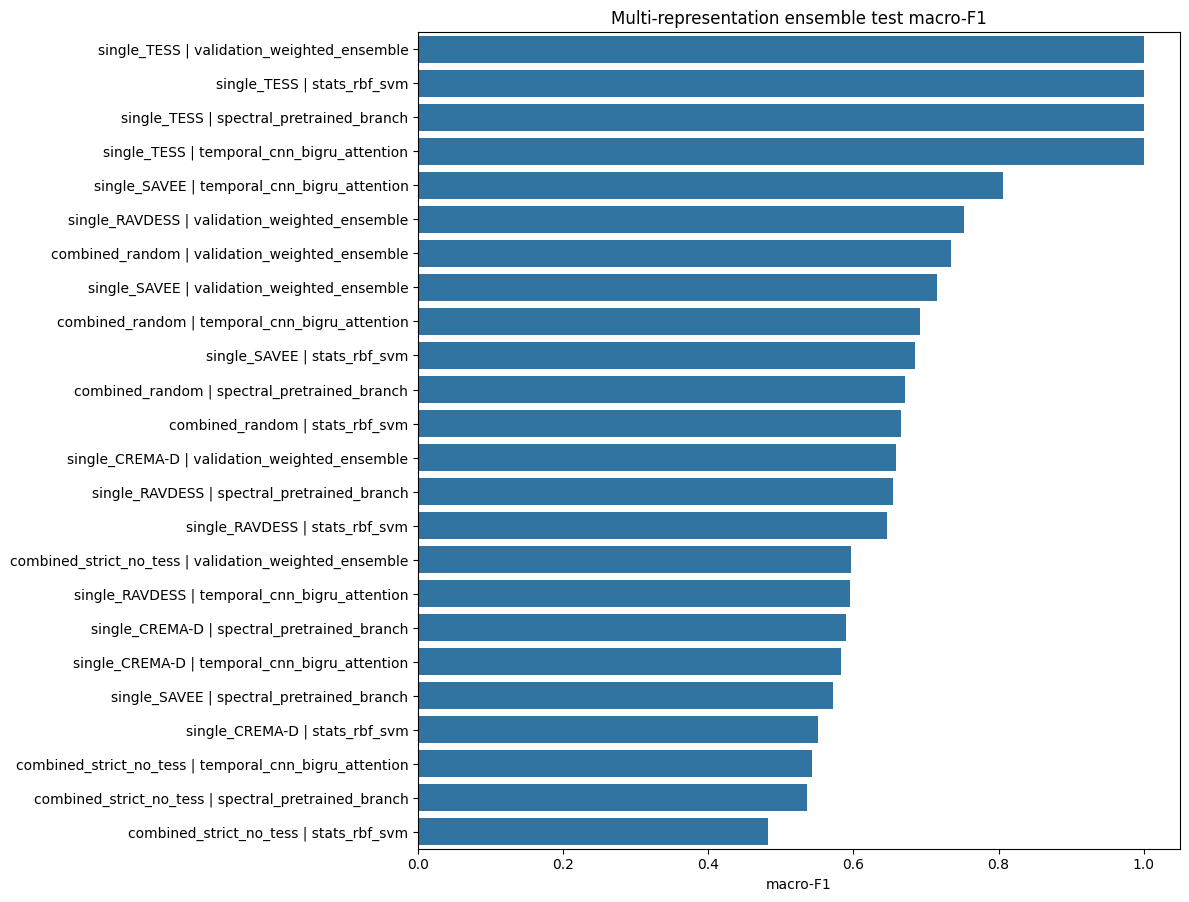

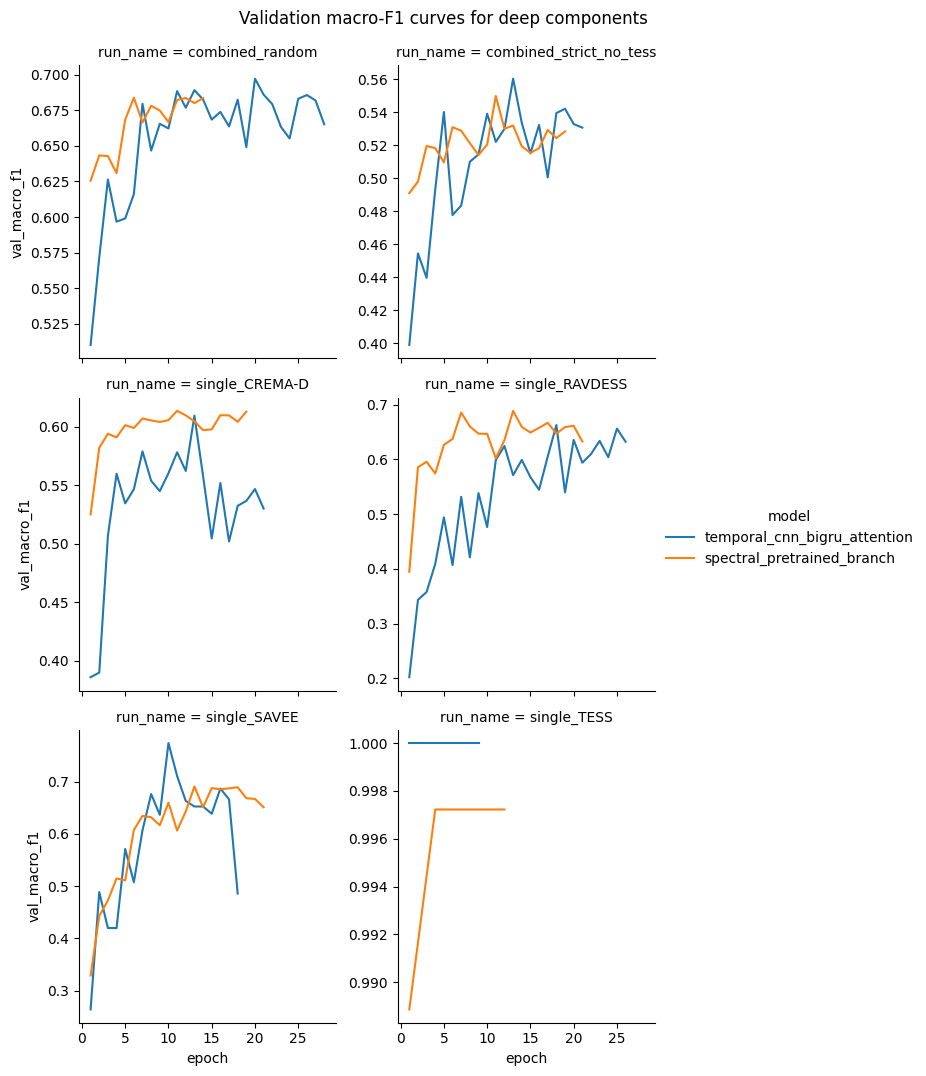

dataset                                                CREMA-D   RAVDESS  \
run_name                model                                              
combined_random         spectral_pretrained_branch    0.579357  0.554035   
                        stats_rbf_svm                 0.554502  0.727331   
                        temporal_cnn_bigru_attention  0.597102  0.659102   
                        validation_weighted_ensemble  0.645249  0.748980   
combined_strict_no_tess spectral_pretrained_branch    0.551421  0.486305   
                        stats_rbf_svm                 0.501964  0.296593   
                        temporal_cnn_bigru_attention  0.556384  0.493258   
                        validation_weighted_ensemble  0.617412  0.461306   
single_CREMA-D          spectral_pretrained_branch    0.589920       NaN   
                        stats_rbf_svm                 0.550703       NaN   
                        temporal_cnn_bigru_attention  0.582518       NaN   
                        validation_weighted_ensemble  0.658321       NaN   
single_RAVDESS          spectral_pretrained_branch         NaN  0.654618   
                        stats_rbf_svm                      NaN  0.645668   
                        temporal_cnn_bigru_attention       NaN  0.595775   
                        validation_weighted_ensemble       NaN  0.751948   
single_SAVEE            spectral_pretrained_branch         NaN       NaN   
                        stats_rbf_svm                      NaN       NaN   
                        temporal_cnn_bigru_attention       NaN       NaN   
                        validation_weighted_ensemble       NaN       NaN   
single_TESS             spectral_pretrained_branch         NaN       NaN   
                        stats_rbf_svm                      NaN       NaN   
                        temporal_cnn_bigru_attention       NaN       NaN   
                        validation_weighted_ensemble       NaN       NaN   

dataset                                                  SAVEE      TESS  
run_name                model                                             
combined_random         spectral_pretrained_branch    0.575926  0.989008  
                        stats_rbf_svm                 0.483466  1.000000  
                        temporal_cnn_bigru_attention  0.537007  1.000000  
                        validation_weighted_ensemble  0.637614  1.000000  
combined_strict_no_tess spectral_pretrained_branch    0.120558       NaN  
                        stats_rbf_svm                 0.253147       NaN  
                        temporal_cnn_bigru_attention  0.128099       NaN  
                        validation_weighted_ensemble  0.136251       NaN  
single_CREMA-D          spectral_pretrained_branch         NaN       NaN  
                        stats_rbf_svm                      NaN       NaN  
                        temporal_cnn_bigru_attention       NaN       NaN  
                        validation_weighted_ensemble       NaN       NaN  
single_RAVDESS          spectral_pretrained_branch         NaN       NaN  
                        stats_rbf_svm                      NaN       NaN  
                        temporal_cnn_bigru_attention       NaN       NaN  
                        validation_weighted_ensemble       NaN       NaN  
single_SAVEE            spectral_pretrained_branch    0.571200       NaN  
                        stats_rbf_svm                 0.684714       NaN  
                        temporal_cnn_bigru_attention  0.805544       NaN  
                        validation_weighted_ensemble  0.715113       NaN  
single_TESS             spectral_pretrained_branch         NaN  1.000000  
                        stats_rbf_svm                      NaN  1.000000  
                        temporal_cnn_bigru_attention       NaN  1.000000  
                        validation_weighted_ensemble       NaN  1.000000

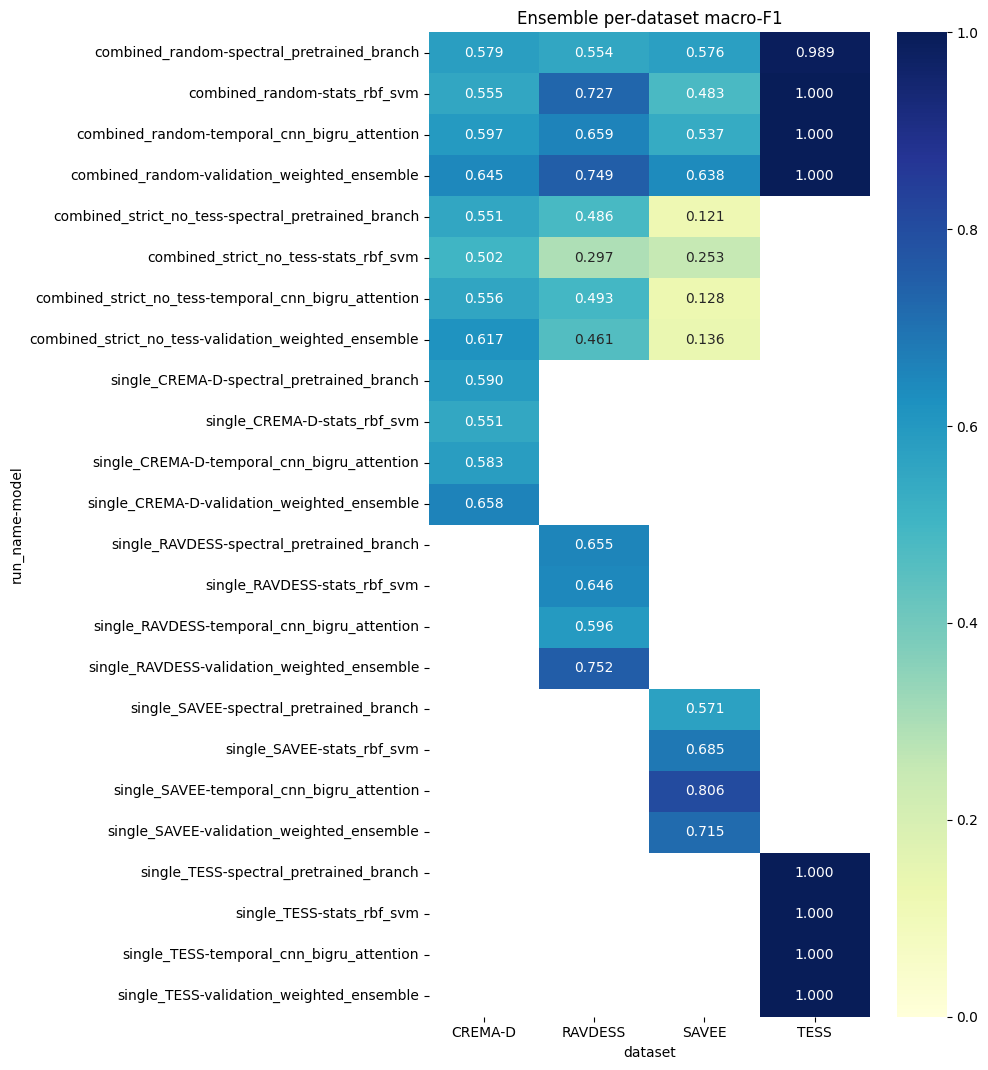

In [17]:
if len(metrics_df):
    plt.figure(figsize=(12, max(5, 0.38 * len(metrics_df))))
    plot_df = metrics_df.copy()
    plot_df["label"] = plot_df["run_name"] + " | " + plot_df["model"]
    plot_df = plot_df.sort_values("macro_f1", ascending=False)
    sns.barplot(data=plot_df, y="label", x="macro_f1", orient="h")
    plt.title("Multi-representation ensemble test macro-F1")
    plt.xlabel("macro-F1")
    plt.ylabel("")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "multi_rep_ensemble_macro_f1.png", dpi=160)
    plt.show()

if len(history_df):
    g = sns.relplot(
        data=history_df,
        x="epoch",
        y="val_macro_f1",
        hue="model",
        col="run_name",
        col_wrap=2,
        kind="line",
        height=3.5,
        facet_kws={"sharey": False},
    )
    g.fig.suptitle("Validation macro-F1 curves for deep components", y=1.02)
    plt.savefig(FIGURE_DIR / "multi_rep_ensemble_validation_curves.png", dpi=160, bbox_inches="tight")
    plt.show()

if len(per_dataset_df):
    pivot = per_dataset_df.pivot_table(index=["run_name", "model"], columns="dataset", values="macro_f1", aggfunc="mean")
    display(pivot)
    plt.figure(figsize=(10, max(4, 0.45 * len(pivot))))
    sns.heatmap(pivot, annot=True, fmt=".3f", cmap="YlGnBu", vmin=0, vmax=1)
    plt.title("Ensemble per-dataset macro-F1")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "multi_rep_ensemble_per_dataset_heatmap.png", dpi=160)
    plt.show()


## 13. Compare with Baseline 04, Dual-view, Tri-view and Literature

Notebook cố gắng tự đọc output cũ nếu có trong workspace/Kaggle. Nếu chưa có, phần comparison vẫn lưu reference rows để dùng trong báo cáo.


,source,protocol,model,accuracy,macro_f1,reported_accuracy_text,note
23,our_05_multi_rep_ensemble,single_TESS,validation_weighted_ensemble,1.000000,1.000000,,New model: unified feature engineering + speci...
22,our_05_multi_rep_ensemble,single_TESS,stats_rbf_svm,1.000000,1.000000,,New model: unified feature engineering + speci...
21,our_05_multi_rep_ensemble,single_TESS,spectral_pretrained_branch,1.000000,1.000000,,New model: unified feature engineering + speci...
20,our_05_multi_rep_ensemble,single_TESS,temporal_cnn_bigru_attention,1.000000,1.000000,,New model: unified feature engineering + speci...
16,our_05_multi_rep_ensemble,single_SAVEE,temporal_cnn_bigru_attention,0.809524,0.805544,,New model: unified feature engineering + speci...
15,our_05_multi_rep_ensemble,single_RAVDESS,validation_weighted_ensemble,0.754717,0.751948,,New model: unified feature engineering + speci...
3,our_05_multi_rep_ensemble,combined_random,validation_weighted_ensemble,0.733216,0.734992,,New model: unified feature engineering + speci...
19,our_05_multi_rep_ensemble,single_SAVEE,validation_weighted_ensemble,0.761905,0.715113,,New model: unified feature engineering + speci...
0,our_05_multi_rep_ensemble,combined_random,temporal_cnn_bigru_attention,0.690813,0.692047,,New model: unified feature engineering + speci...
18,our_05_multi_rep_ensemble,single_SAVEE,stats_rbf_svm,0.714286,0.684714,,New model: unified feature engineering + speci...


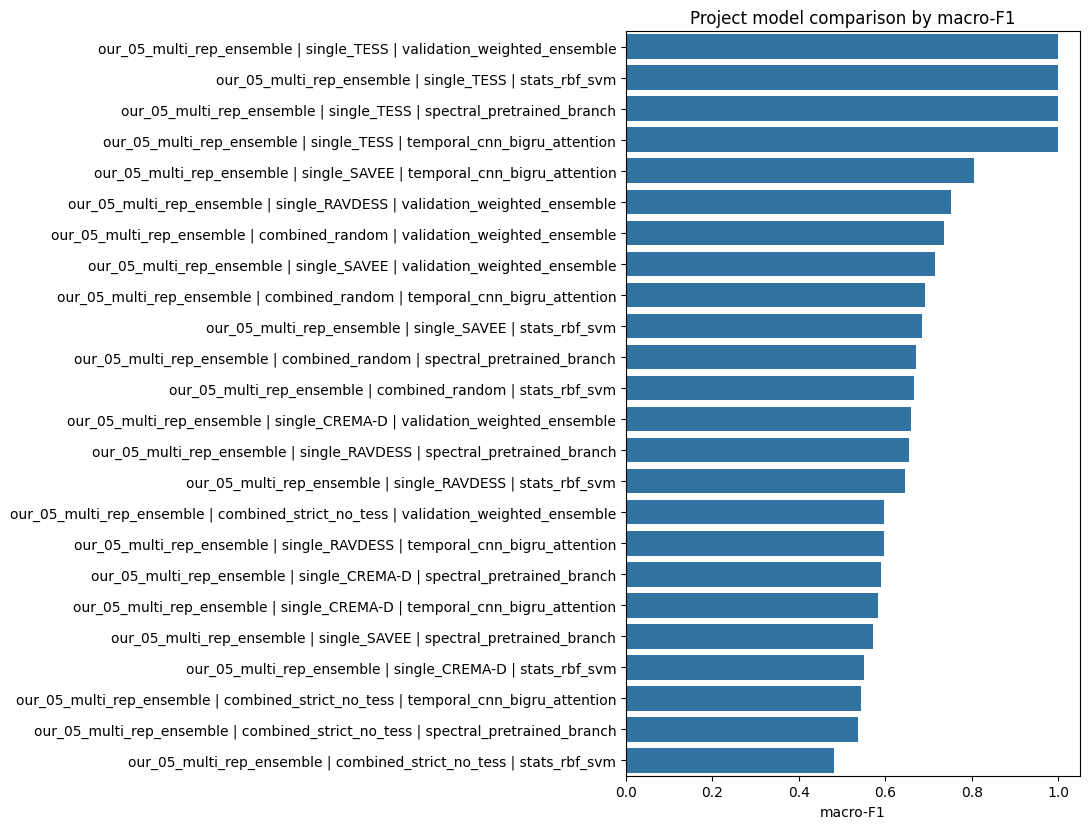

,model,protocol,reported_accuracy_text,note
0,Ahmed et al. weighted ensemble 1D-CNN + CNN-LS...,"single-dataset, not clearly speaker-aware",TESS 99.46%; RAVDESS 95.62%; SAVEE 93.22%; CRE...,"Uses handcrafted features, augmentation, recur..."
1,Lee & Nadeem MFCC 1D-CNN with channel/spatial ...,"single-dataset benchmark, split not clearly st...",SAVEE 97.49%; RAVDESS 99.23%; CREMA-D 89.31%; ...,Attention reweights informative MFCC channels ...
2,Chowdhury et al. DCRF-BiLSTM feature engineering,"individual and combined datasets, not clearly ...",RAVDESS 97.83%; SAVEE 97.02%; CREMA-D 95.10%; ...,"Uses richer acoustic features, augmentation, B..."


In [18]:
comparison_rows = []

baseline_candidates = [
    PROJECT_ROOT / "04_Baseline_Per_Dataset_outputs" / "reports" / "baseline_per_dataset_metrics.csv",
    Path.cwd().parent / "04_Baseline_Models" / "reports" / "baseline_per_dataset_metrics.csv",
    Path("D:/UTE/Speech Programming/Speech Project/04_Baseline_Models/reports/baseline_per_dataset_metrics.csv"),
]
for p in baseline_candidates:
    if p.exists():
        base_df = pd.read_csv(p)
        for _, r in base_df.iterrows():
            comparison_rows.append({
                "source": "our_04_baseline",
                "protocol": r.get("experiment", ""),
                "model": f"{r.get('feature_set', '')}_{r.get('model', '')}",
                "accuracy": r.get("accuracy", np.nan),
                "macro_f1": r.get("macro_f1", np.nan),
                "reported_accuracy_text": "",
                "note": "Classical baseline.",
            })
        print("Loaded baseline:", p)
        break

old_candidates = [
    ("our_05_dual", Path.cwd().parent / "05_Main_Model" / "outputs" / "05_Dual_View_Stronger_SER" / "reports" / "stronger_dual_metrics.csv"),
    ("our_05_tri_gated", Path.cwd().parent / "05_Main_Model" / "outputs" / "05_Tri_View_Fusion_SER" / "05_Tri_View_Fusion_outputs" / "reports" / "tri_view_metrics.csv"),
]
for source, p in old_candidates:
    if p.exists():
        df = pd.read_csv(p)
        model_col = "variant" if "variant" in df.columns else "model"
        run_col = "run_name"
        for _, r in df.iterrows():
            comparison_rows.append({
                "source": source,
                "protocol": r.get(run_col, ""),
                "model": r.get(model_col, ""),
                "accuracy": r.get("accuracy", np.nan),
                "macro_f1": r.get("macro_f1", np.nan),
                "reported_accuracy_text": "",
                "note": "Previous 05 output.",
            })
        print("Loaded previous output:", p)

for _, r in metrics_df.iterrows():
    comparison_rows.append({
        "source": "our_05_multi_rep_ensemble",
        "protocol": r.get("run_name", ""),
        "model": r.get("model", ""),
        "accuracy": r.get("accuracy", np.nan),
        "macro_f1": r.get("macro_f1", np.nan),
        "reported_accuracy_text": "",
        "note": "New model: unified feature engineering + specialized models + validation-weighted ensemble.",
    })

reference_rows = [
    {
        "source": "reference",
        "protocol": "single-dataset, not clearly speaker-aware",
        "model": "Ahmed et al. weighted ensemble 1D-CNN + CNN-LSTM + CNN-GRU",
        "accuracy": np.nan,
        "macro_f1": np.nan,
        "reported_accuracy_text": "TESS 99.46%; RAVDESS 95.62%; SAVEE 93.22%; CREMA-D 90.47%",
        "note": "Uses handcrafted features, augmentation, recurrent variants and weighted ensemble.",
    },
    {
        "source": "reference",
        "protocol": "single-dataset benchmark, split not clearly strict speaker-aware",
        "model": "Lee & Nadeem MFCC 1D-CNN with channel/spatial attention",
        "accuracy": np.nan,
        "macro_f1": np.nan,
        "reported_accuracy_text": "SAVEE 97.49%; RAVDESS 99.23%; CREMA-D 89.31%; TESS 99.82%",
        "note": "Attention reweights informative MFCC channels and time regions.",
    },
    {
        "source": "reference",
        "protocol": "individual and combined datasets, not clearly strict speaker-aware",
        "model": "Chowdhury et al. DCRF-BiLSTM feature engineering",
        "accuracy": np.nan,
        "macro_f1": np.nan,
        "reported_accuracy_text": "RAVDESS 97.83%; SAVEE 97.02%; CREMA-D 95.10%; TESS 100%; R+T+S+E+C 93.76%",
        "note": "Uses richer acoustic features, augmentation, BiLSTM temporal context and DeepCRF.",
    },
]

comparison_df = pd.DataFrame(comparison_rows)
reference_df = pd.DataFrame(reference_rows)
comparison_df.to_csv(REPORT_DIR / "baseline_dual_tri_vs_multi_rep_comparison.csv", index=False)
reference_df.to_csv(REPORT_DIR / "reference_model_literature_comparison.csv", index=False)

if len(comparison_df):
    display(comparison_df.sort_values("macro_f1", ascending=False, na_position="last"))
    plot_df = comparison_df.dropna(subset=["macro_f1"]).copy()
    plot_df["label"] = plot_df["source"] + " | " + plot_df["protocol"].astype(str) + " | " + plot_df["model"].astype(str)
    plot_df = plot_df.sort_values("macro_f1", ascending=False).head(35)
    plt.figure(figsize=(11, max(5, 0.35 * len(plot_df))))
    sns.barplot(data=plot_df, y="label", x="macro_f1", orient="h")
    plt.title("Project model comparison by macro-F1")
    plt.xlabel("macro-F1")
    plt.ylabel("")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "project_model_comparison_macro_f1.png", dpi=160)
    plt.show()

display(reference_df[["model", "protocol", "reported_accuracy_text", "note"]])


## 14. Save Summary and Package ZIP

Cell cuối tạo ZIP trong `/kaggle/working` khi chạy trên Kaggle. File nên tải là:

```text
/kaggle/working/05_Multi_Representation_Ensemble_outputs_with_notebook.zip
```


In [19]:
summary = {
    "notebook": "05_Multi_Representation_Ensemble_SER",
    "architecture": "Unified feature engineering -> 3 branches: temporal CNN-BiGRU-attention + pretrained spectrogram branch + stats RBF-SVM -> validation-weighted ensemble",
    "output_dir": str(OUTPUT_DIR),
    "metrics_csv": str(REPORT_DIR / "multi_rep_ensemble_metrics.csv"),
    "weights_csv": str(REPORT_DIR / "multi_rep_ensemble_weights.csv"),
    "spectral_branch_mode": SPECTRAL_BRANCH_MODE,
    "spectral_pretrained_model": SPECTRAL_PRETRAINED_MODEL if SPECTRAL_BRANCH_MODE == "pretrained" else None,
    "notes": "Use validation macro-F1 for model selection; compare random, strict and single-dataset protocols separately.",
}
with open(REPORT_DIR / "multi_rep_ensemble_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

zip_base = PROJECT_ROOT / "05_Multi_Representation_Ensemble_outputs_package"
zip_path = shutil.make_archive(str(zip_base), "zip", OUTPUT_DIR)
print("OUTPUT ZIP:", zip_path)

PACKAGE_DIR = PROJECT_ROOT / "05_Multi_Representation_Ensemble_export_package"
PACKAGE_DIR.mkdir(parents=True, exist_ok=True)

export_outputs_dir = PACKAGE_DIR / OUTPUT_DIR.name
if export_outputs_dir.exists():
    shutil.rmtree(export_outputs_dir)
shutil.copytree(OUTPUT_DIR, export_outputs_dir)

candidate_notebooks = []
candidate_notebooks.extend(Path("/kaggle/working").glob("*.ipynb"))
candidate_notebooks.extend(Path.cwd().glob("*.ipynb"))
candidate_notebooks = list(dict.fromkeys(candidate_notebooks))
preferred = [p for p in candidate_notebooks if "05" in p.name and ("Multi" in p.name or "Ensemble" in p.name)]
notebook_to_copy = preferred[0] if preferred else (candidate_notebooks[0] if candidate_notebooks else None)

if notebook_to_copy is not None and notebook_to_copy.exists():
    copied_nb = PACKAGE_DIR / notebook_to_copy.name
    shutil.copy2(notebook_to_copy, copied_nb)
    print("Included notebook:", copied_nb)
else:
    print("Warning: could not auto-find executed notebook. Outputs are still packaged.")

manifest = {
    "notebook": "05_Multi_Representation_Ensemble_SER",
    "output_dir": str(OUTPUT_DIR),
    "included_outputs_dir": str(export_outputs_dir),
    "included_notebook": str(notebook_to_copy) if notebook_to_copy is not None else None,
    "metrics_csv": str(REPORT_DIR / "multi_rep_ensemble_metrics.csv"),
    "summary_json": str(REPORT_DIR / "multi_rep_ensemble_summary.json"),
}
with open(PACKAGE_DIR / "export_manifest.json", "w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=2, ensure_ascii=False)

FINAL_ZIP_BASE = PROJECT_ROOT / "05_Multi_Representation_Ensemble_outputs_with_notebook"
FINAL_ZIP_PATH = shutil.make_archive(str(FINAL_ZIP_BASE), "zip", PACKAGE_DIR)
print("FINAL ZIP:", FINAL_ZIP_PATH)

try:
    from IPython.display import FileLink, display
    display(FileLink(str(FINAL_ZIP_PATH)))
    display(FileLink(str(zip_path)))
except Exception as e:
    print("Download link display failed:", e)
    print("You can download it from:", FINAL_ZIP_PATH)


OUTPUT ZIP: /kaggle/working/05_Multi_Representation_Ensemble_outputs_package.zip
FINAL ZIP: /kaggle/working/05_Multi_Representation_Ensemble_outputs_with_notebook.zip


/kaggle/working/05_Multi_Representation_Ensemble_outputs_with_notebook.zip

/kaggle/working/05_Multi_Representation_Ensemble_outputs_package.zip